# Nivel 2: clasificador de codigos y cascada jerarquica

Segundo nivel del clasificador jerarquico (codigos CIE-10 completos) y la inferencia en
cascada que encadena ambos niveles. Parte de un modelo de nivel 1 ya entrenado.

La comparativa de modelos de nivel 1 vive en los cuadernos 1 (RoBERTa), 2 (RigoBERTa),
4 (ModernBERT) y 5 (mmBERT): aqui no se repite.


## 1. Configuración e Importación

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

# Verificar/instalar dependencias
try:
    import torch
    import transformers
    import datasets
except ImportError:
    print(" Instalando dependencias...")
    !{sys.executable} -m pip install -q torch transformers datasets scikit-learn pandas numpy tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report
from tqdm.auto import tqdm
import os
import json
from pathlib import Path
from collections import defaultdict
import re

# ============================================================================
# CONFIGURACIÓN
# ============================================================================
# Flag para activar/desactivar limpieza de texto
CLEAN_TEXT = True  # Cambiar a True si quieres limpiar el texto

# Configuración
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"  Dispositivo: {device}")
if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
else:
    print("     CPU detectado (entrenamiento será más lento)")

# Rutas
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT.parent / "csv_import_scripts" / "codiesp_csvs"
SNAPSHOTS_DIR = PROJECT_ROOT / "snapshots"
LEVEL1_DIR = SNAPSHOTS_DIR / "nivel1_capitulos"
LEVEL2_DIR = SNAPSHOTS_DIR / "nivel2_codigos"

# Crear directorios
for dir_path in [SNAPSHOTS_DIR, LEVEL1_DIR, LEVEL2_DIR]:

    dir_path.mkdir(exist_ok=True, parents=True)

print(f"\n Limpieza de texto: {' ACTIVADA' if CLEAN_TEXT else ' DESACTIVADA'}")

print(f"\n Rutas:")
print(f"   Dataset: {DATA_DIR}")
print(f"   Nivel 1: {LEVEL1_DIR}")
print(f"   Nivel 2: {LEVEL2_DIR}")

  Dispositivo: cuda
   GPU: NVIDIA GeForce RTX 4080

 Limpieza de texto:  ACTIVADA

 Rutas:
   Dataset: /home/cie10user/csv_import_scripts/codiesp_csvs
   Nivel 1: /home/cie10user/bert-classifier/snapshots/nivel1_capitulos
   Nivel 2: /home/cie10user/bert-classifier/snapshots/nivel2_codigos


## 2. Configuración de Hiperparámetros

In [2]:
from huggingface_hub import login

class Config:
    """Configuración global del sistema"""

    # HuggingFace Token
    HF_TOKEN = os.getenv("HF_TOKEN", None)

    # ============================================================================
    # MODELOS DISPONIBLES
    # ============================================================================

    # 1. RoBERTa Médico Español (Baseline)
    MODEL_ROBERTA_MEDICAL = 'PlanTL-GOB-ES/roberta-base-biomedical-clinical-es'
    ROBERTA_MAX_LENGTH = 512
    ROBERTA_BATCH_SIZE = 16 if device.type == 'cuda' else 8

    # 3. mmBERT (Modern Multilingual BERT - 100+ idiomas)
    MODEL_MMBERT = 'jhu-clsp/mmBERT-base'
    MMBERT_MAX_LENGTH = 1500  # Soporta hasta 4096 pero usamos 1500 para balance
    MMBERT_BATCH_SIZE = 12 if device.type == 'cuda' else 6

    # 4. ModernBERT (Estado del arte 2024 - Flash Attention)
    MODEL_MODERNBERT = 'answerdotai/ModernBERT-base'
    MODERNBERT_MAX_LENGTH = 1500  # Máximo contexto
    MODERNBERT_BATCH_SIZE = 4 if device.type == 'cuda' else 2  # Muy largo, reduce batch

    # Modelo por defecto para inicio rápido
    MODEL_NAME = MODEL_ROBERTA_MEDICAL
    MAX_LENGTH = ROBERTA_MAX_LENGTH

    # ============================================================================
    # ENTRENAMIENTO
    # ============================================================================

    # Batch sizes - Adaptativo según hardware
    if device.type == 'cuda':
        BATCH_SIZE_LEVEL1 = 16  # Nivel 1 (solo 19 clases)
        BATCH_SIZE_LEVEL2 = 8   # Nivel 2 (más clases por capítulo)
        ACCUMULATION_STEPS = 2
    else:
        BATCH_SIZE_LEVEL1 = 8   # CPU
        BATCH_SIZE_LEVEL2 = 4
        ACCUMULATION_STEPS = 4

    # DataLoader workers
    #  IMPORTANTE: En Jupyter notebooks, SIEMPRE usar NUM_WORKERS = 0
    # Razón: PyTorch con num_workers > 0 usa multiprocessing (spawn) que intenta
    # serializar las clases Dataset con pickle. Las clases definidas en notebooks
    # están en el módulo '__main__' que no se puede serializar correctamente.
    # Error típico: "AttributeError: module '__main__' has no attribute 'ChapterDataset'"
    # Solución: num_workers=0 ejecuta todo en el proceso principal sin multiprocessing.
    # En scripts .py normales, puedes usar NUM_WORKERS = 2-4 para acelerar carga de datos.
    NUM_WORKERS = 0  # SIEMPRE 0 en Jupyter notebooks

    # Épocas
    EPOCHS_LEVEL1 = 100  # Nivel 1 (parará antes con early stopping si converge)
    EPOCHS_LEVEL2 = 60  # Nivel 2 (parará antes con early stopping si converge)
    EARLY_STOPPING_PATIENCE = 20  # Parar si no mejora en sucesivas épocas
    MIN_DELTA = 0.0001  # Mejora mínima para considerar que hubo progreso

    # Optimización
    LEARNING_RATE = 3e-5
    WARMUP_RATIO = 0.1
    WEIGHT_DECAY = 0.01
    MAX_GRAD_NORM = 1.0
    DROPOUT = 0.1

    # Dataset
    TRAIN_PATH = DATA_DIR / 'codiesp_D_source_train.csv'
    VAL_PATH = DATA_DIR / 'codiesp_D_source_validation.csv'
    TEST_PATH = DATA_DIR / 'codiesp_D_source_test.csv'

    # Cascada
    TOP_K_CHAPTERS = 3  # Top-3 capítulos en Nivel 1
    TOP_K_CODES_PER_CHAPTER = 5  # Top-5 códigos por capítulo
    FINAL_TOP_K = 10  # Top-10 códigos finales

    # Paths
    LEVEL1_DIR = LEVEL1_DIR
    LEVEL2_DIR = LEVEL2_DIR

    # Umbrales
    #  IMPORTANTE: Thresholds bajos permiten más recall, altos más precision
    # Ajustar según distribución real de labels por documento (ver celda de análisis)
    THRESHOLD_LEVEL1 = 0.3  # Umbral para capítulos (0.3 = más permisivo)
    THRESHOLD_LEVEL2 = 0.3  # Umbral para códigos (0.3 recomendado vs 0.5 muy restrictivo)

config = Config()

# Configurar HuggingFace login
if config.HF_TOKEN:
    try:
        login(token=config.HF_TOKEN)
        print(" HuggingFace login exitoso")
    except Exception as e:
        print(f" Error en HF login: {e}")
else:
    print(" HF_TOKEN no configurado (export HF_TOKEN='tu_token')")

print("\n  Configuración:")
print(f"   Modelo por defecto: {config.MODEL_NAME}")
print(f"   Max Length: {config.MAX_LENGTH}")
print(f"   Batch Level 1: {config.BATCH_SIZE_LEVEL1}")
print(f"   Batch Level 2: {config.BATCH_SIZE_LEVEL2}")
print(f"   Épocas Level 1: {config.EPOCHS_LEVEL1}")
print(f"   Épocas Level 2: {config.EPOCHS_LEVEL2}")
print(f"   Cascada: Top-{config.TOP_K_CHAPTERS} capítulos → Top-{config.TOP_K_CODES_PER_CHAPTER} códigos/cap")
print(f"   Output final: Top-{config.FINAL_TOP_K} códigos")

print("\n Modelos disponibles:")
print(f"   1. RoBERTa Médico:  {config.MODEL_ROBERTA_MEDICAL} ({config.ROBERTA_MAX_LENGTH} tokens)")
print(f"   3. mmBERT:          {config.MODEL_MMBERT} ({config.MMBERT_MAX_LENGTH} tokens)")
print(f"   4. ModernBERT:      {config.MODEL_MODERNBERT} ({config.MODERNBERT_MAX_LENGTH} tokens)")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


 HuggingFace login exitoso

  Configuración:
   Modelo por defecto: PlanTL-GOB-ES/roberta-base-biomedical-clinical-es
   Max Length: 512
   Batch Level 1: 16
   Batch Level 2: 8
   Épocas Level 1: 100
   Épocas Level 2: 60
   Cascada: Top-3 capítulos → Top-5 códigos/cap
   Output final: Top-10 códigos

 Modelos disponibles:
   1. RoBERTa Médico:  PlanTL-GOB-ES/roberta-base-biomedical-clinical-es (512 tokens)
   3. mmBERT:          jhu-clsp/mmBERT-base (1500 tokens)
   4. ModernBERT:      answerdotai/ModernBERT-base (1500 tokens)


In [3]:
# Preparacion: este cuaderno parte de un modelo de nivel 1 ya entrenado. Los cuadernos 1, 2,
# 4 y 5 dejan su mejor checkpoint en snapshots/nivel1_capitulos/; aqui se toma el de RoBERTa,
# que es el candidato con mejor resultado en el cribado de capitulos.
best_model_path = config.LEVEL1_DIR / "best_model_roberta_baseline.pt"
assert best_model_path.exists(), (
    f"Falta {best_model_path}. Ejecuta antes el cuaderno de nivel 1 correspondiente."
)

# El tokenizador lo creaban las celdas de nivel 1; aqui se crea explicitamente.
tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)

# El historial acumulado lo alimentan las celdas de entrenamiento; aqui arranca vacio.
all_training_histories = []
print(f" Nivel 1 de partida: {best_model_path.name}")


 Nivel 1 de partida: best_model_roberta_baseline.pt


###  Comparación de Modelos Disponibles

| Modelo | Max Tokens | Idiomas | Dominio | Batch Size | Velocidad | Ventajas |
|--------|------------|---------|---------|------------|-----------|----------|
| **RoBERTa Médico** | 512 | Español | Médico | 16 |  Rápido | Conocimiento médico español |
| **Longformer** | 4096 | Inglés | General | 8 |  Medio | Textos muy largos |
| **mmBERT** | 1500 | 100+ | General | 12 |  Medio | Multilingüe + textos largos |
| **ModernBERT** | 8192 | Inglés | General | 4 |  Lento | Ultra-largos + Flash Attention |

**Recomendaciones:**
- **Textos < 512 tokens:** RoBERTa Médico (mejor conocimiento de dominio)
- **Textos 512-2048:** mmBERT (multilingüe + buen balance)
- **Textos 2048-4096:** Longformer (si inglés es aceptable)
- **Textos > 4096:** ModernBERT (máxima capacidad)

## 3. Mapeo de Capítulos CIE-10

In [4]:
# Mapeo oficial de capítulos CIE-10 (usando letras como keys)
CIE10_CHAPTERS = {
    'A': {'name': 'Enfermedades infecciosas y parasitarias', 'range': 'A00-B99', 'roman': 'I'},
    'C': {'name': 'Neoplasias', 'range': 'C00-D48', 'roman': 'II'},
    'D': {'name': 'Enfermedades de la sangre', 'range': 'D50-D89', 'roman': 'III'},
    'E': {'name': 'Enfermedades endocrinas, nutricionales y metabólicas', 'range': 'E00-E90', 'roman': 'IV'},
    'F': {'name': 'Trastornos mentales y del comportamiento', 'range': 'F00-F99', 'roman': 'V'},
    'G': {'name': 'Enfermedades del sistema nervioso', 'range': 'G00-G99', 'roman': 'VI'},
    'H': {'name': 'Enfermedades del ojo y oído', 'range': 'H00-H95', 'roman': 'VII-VIII'},
    'I': {'name': 'Enfermedades del sistema circulatorio', 'range': 'I00-I99', 'roman': 'IX'},
    'J': {'name': 'Enfermedades del sistema respiratorio', 'range': 'J00-J99', 'roman': 'X'},
    'K': {'name': 'Enfermedades del sistema digestivo', 'range': 'K00-K93', 'roman': 'XI'},
    'L': {'name': 'Enfermedades de la piel y del tejido subcutáneo', 'range': 'L00-L99', 'roman': 'XII'},
    'M': {'name': 'Enfermedades del sistema osteomuscular', 'range': 'M00-M99', 'roman': 'XIII'},
    'N': {'name': 'Enfermedades del sistema genitourinario', 'range': 'N00-N99', 'roman': 'XIV'},
    'O': {'name': 'Embarazo, parto y puerperio', 'range': 'O00-O99', 'roman': 'XV'},
    'P': {'name': 'Afecciones originadas en el período perinatal', 'range': 'P00-P96', 'roman': 'XVI'},
    'Q': {'name': 'Malformaciones congénitas', 'range': 'Q00-Q99', 'roman': 'XVII'},
    'R': {'name': 'Síntomas, signos y hallazgos anormales', 'range': 'R00-R99', 'roman': 'XVIII'},
    'S': {'name': 'Traumatismos, envenenamientos', 'range': 'S00-T98', 'roman': 'XIX'},
    'V': {'name': 'Causas externas de morbilidad y mortalidad', 'range': 'V01-Y98', 'roman': 'XX'},
    'Z': {'name': 'Factores que influyen en el estado de salud', 'range': 'Z00-Z99', 'roman': 'XXI'},
}

def extract_chapter_from_code(code):
    """Extraer capítulo CIE-10 del código (retorna letra)"""
    if not code or len(code) == 0:
        return None

    # Obtener primera letra del código
    first_letter = code[0].upper()

    # Mapeo directo letra → capítulo
    # Casos especiales:
    if first_letter == 'B':
        return 'A'  # B pertenece al capítulo A (infecciosas)
    elif first_letter == 'D':
        # D00-D48 = Neoplasias (C), D50-D89 = Sangre (D)
        if len(code) > 1:
            try:
                num = int(code[1:3])
                if num >= 50:
                    return 'D'  # Enfermedades de la sangre
            except:
                pass
        return 'C'  # Neoplasias
    elif first_letter == 'T':
        return 'S'  # T pertenece a traumatismos (S)
    elif first_letter in ['W', 'X', 'Y']:
        return 'V'  # Pertenecen a causas externas (V)

    # Resto de letras son mapeo directo
    if first_letter in CIE10_CHAPTERS:
        return first_letter

    return None

print(f" Capítulos CIE-10 definidos: {len(CIE10_CHAPTERS)}")
print(f"\n Ejemplos de DIRECT mapping (letra = capítulo):")
direct_codes = ['A00', 'C50', 'E11', 'I10', 'J44', 'M79']
for code in direct_codes:
    chapter = extract_chapter_from_code(code)
    if chapter:
        print(f"   {code} → Cap. {chapter}: {CIE10_CHAPTERS[chapter]['name']}")

print(f"\n  Ejemplos de EDGE CASES (letra ≠ capítulo):")
edge_codes = [
    ('B15', 'B→A: Hepatitis A es infecciosa'),
    ('D05', 'D→C: Neoplasia in situ (D<50)'),
    ('D50', 'D→D: Anemia (D≥50)'),
    ('T14', 'T→S: Traumatismo'),
    ('W19', 'W→V: Caída (causa externa)'),
    ('X59', 'X→V: Exposición a factores'),
    ('Y84', 'Y→V: Complicación de procedimiento')
]
for code, description in edge_codes:
    chapter = extract_chapter_from_code(code)
    if chapter:
        print(f"   {code} → Cap. {chapter} ({description})")

 Capítulos CIE-10 definidos: 20

 Ejemplos de DIRECT mapping (letra = capítulo):
   A00 → Cap. A: Enfermedades infecciosas y parasitarias
   C50 → Cap. C: Neoplasias
   E11 → Cap. E: Enfermedades endocrinas, nutricionales y metabólicas
   I10 → Cap. I: Enfermedades del sistema circulatorio
   J44 → Cap. J: Enfermedades del sistema respiratorio
   M79 → Cap. M: Enfermedades del sistema osteomuscular

  Ejemplos de EDGE CASES (letra ≠ capítulo):
   B15 → Cap. A (B→A: Hepatitis A es infecciosa)
   D05 → Cap. C (D→C: Neoplasia in situ (D<50))
   D50 → Cap. D (D→D: Anemia (D≥50))
   T14 → Cap. S (T→S: Traumatismo)
   W19 → Cap. V (W→V: Caída (causa externa))
   X59 → Cap. V (X→V: Exposición a factores)
   Y84 → Cap. V (Y→V: Complicación de procedimiento)


###  Explicación del Mapeo de Capítulos CIE-10

**¿Por qué este mapeo?**

La CIE-10 oficial usa **21 capítulos con numeración romana** (I-XXI), pero los **códigos reales usan letras** que NO siempre coinciden con el número de capítulo. Esto crea inconsistencias históricas de la OMS.

---

###  Capítulos que Juntan Múltiples Letras (NO Direct Mapping)

#### **1. Capítulo A (Infecciosas): A00-B99**
**¿Por qué?** La OMS decidió que códigos `A` y `B` pertenecen al mismo capítulo semántico.

**Ejemplos:**
- `A00` → Cólera → Capítulo **A**  (direct mapping)
- `A09` → Diarrea infecciosa → Capítulo **A** 
- `B15` → Hepatitis A → Capítulo **A**  (letra B, pero capítulo A)
- `B34` → Infección viral no especificada → Capítulo **A** 
- `B99` → Otras enfermedades infecciosas → Capítulo **A** 

**Regla:** `B → A` (todas las B son infecciosas)

---

#### **2. Capítulo C (Neoplasias): C00-D48**
**¿Por qué?** Las neoplasias incluyen tumores malignos (C) y benignos/inciertos (D00-D48).

**Ejemplos:**
- `C50` → Tumor maligno de mama → Capítulo **C**  (direct mapping)
- `C34` → Tumor maligno de bronquios y pulmón → Capítulo **C** 
- `D05` → Carcinoma in situ de mama → Capítulo **C**  (letra D, pero capítulo C)
- `D23` → Nevus melanocítico → Capítulo **C** 
- `D48` → Tumor de comportamiento incierto → Capítulo **C** 

**Regla:** `D00-D48 → C` (neoplasias benignas/inciertas)

---

#### **3. Capítulo D (Sangre): D50-D89**
**¿Por qué?** Después de D48, los códigos D50+ cambian a enfermedades de la sangre.

**Ejemplos:**
- `D50` → Anemia por deficiencia de hierro → Capítulo **D** 
- `D64` → Otras anemias → Capítulo **D** 
- `D68` → Trastornos de la coagulación → Capítulo **D** 
- `D89` → Trastornos inmunitarios → Capítulo **D** 

**Regla:** `D50-D89 → D` (enfermedades de la sangre)

** EDGE CASE CRÍTICO:** 
- `D10` → Neoplasia → Capítulo **C**
- `D50` → Anemia → Capítulo **D**
- **Misma letra, diferentes capítulos** (se diferencia por número)

---

#### **4. Capítulo S (Traumatismos): S00-T98**
**¿Por qué?** Lesiones, traumatismos y envenenamientos se agrupan semánticamente.

**Ejemplos:**
- `S62` → Fractura de muñeca → Capítulo **S**  (direct mapping)
- `S06` → Traumatismo intracraneal → Capítulo **S** 
- `T14` → Traumatismo de región no especificada → Capítulo **S**  (letra T, pero capítulo S)
- `T30` → Quemadura térmica → Capítulo **S** 
- `T88` → Complicaciones de atención médica → Capítulo **S** 

**Regla:** `T → S` (todas las T son traumatismos/lesiones)

---

#### **5. Capítulo V (Causas Externas): V01-Y98**
**¿Por qué?** Incluye accidentes, violencia, circunstancias de lesión (códigos V, W, X, Y).

**Ejemplos:**
- `V01` → Peatón lesionado por vehículo → Capítulo **V**  (direct mapping)
- `V89` → Accidente de tránsito → Capítulo **V** 
- `W19` → Caída no especificada → Capítulo **V**  (letra W)
- `X59` → Exposición a factores no especificados → Capítulo **V**  (letra X)
- `Y84` → Complicación de dispositivo médico → Capítulo **V**  (letra Y)

**Regla:** `W, X, Y → V` (causas externas)

---

###  Capítulos con Direct Mapping (Letra = Capítulo)

Estos son más simples:
- `E11` → Diabetes tipo 2 → Capítulo **E** 
- `F32` → Depresión → Capítulo **F** 
- `G40` → Epilepsia → Capítulo **G** 
- `H25` → Catarata → Capítulo **H** 
- `I10` → Hipertensión → Capítulo **I** 
- `J44` → EPOC → Capítulo **J** 
- `K29` → Gastritis → Capítulo **K** 
- `L40` → Psoriasis → Capítulo **L** 
- `M79` → Dolor muscular → Capítulo **M** 
- `N18` → Enfermedad renal crónica → Capítulo **N** 
- `O80` → Parto único espontáneo → Capítulo **O** 
- `P07` → Recién nacido prematuro → Capítulo **P** 
- `Q21` → Malformación cardíaca congénita → Capítulo **Q** 
- `R10` → Dolor abdominal → Capítulo **R** 
- `Z00` → Examen médico general → Capítulo **Z** 

---

###  Resumen de Mapeo No Directo

| Letra Código | Capítulo Real | Razón |
|--------------|---------------|-------|
| **B** | A (Infecciosas) | Misma categoría semántica |
| **D00-D48** | C (Neoplasias) | Neoplasias benignas/inciertas |
| **D50-D89** | D (Sangre) | **Split numérico crítico** |
| **T** | S (Traumatismos) | Lesiones y envenenamientos |
| **W, X, Y** | V (Causas externas) | Circunstancias de lesión |

**Total:** 5 casos especiales de 26 letras posibles (19% edge cases)

**Estrategia del modelo:** Al clasificar primero por capítulo (20 clases) en lugar de 14,000 códigos directamente, reducimos espacio de búsqueda 95% y mejoramos precisión.

## 4. Carga y Preprocesamiento de Datos

In [5]:
# DEBUG: Ver columnas del CSV
print(" Verificando estructura del CSV...")
test_df = pd.read_csv(config.TRAIN_PATH, sep=',', nrows=2)
print(f"Columnas encontradas: {test_df.columns.tolist()}")
print(f"\nPrimeras 2 filas:")
print(test_df.head(2))

 Verificando estructura del CSV...
Columnas encontradas: ['text', 'labels']

Primeras 2 filas:
                                                text  \
0  Describimos el caso de un varón de 37 años con...   
1  Se trata de una mujer de 29 años sometida a un...   

                                              labels  
0  n44.8;z20.818;r60.9;r52;a23.9;i83.90;i87.8;r50...  
1                                          d30.3;r58  


In [6]:
print(" Cargando datos CODIESP...")

# Cargar datos
train_df = pd.read_csv(config.TRAIN_PATH, sep=',')
dev_df = pd.read_csv(config.VAL_PATH, sep=',')

print(f" Train: {len(train_df)} documentos")
print(f" Dev: {len(dev_df)} documentos")

# Análisis de códigos CIE-10 y distribución por documento
all_codes = set()
chapter_counts = {}
codes_per_doc = []
chapters_per_doc = []

for codes_str in train_df['labels'].dropna():
    codes = [c.strip() for c in codes_str.split(';') if c.strip()]
    all_codes.update(codes)
    codes_per_doc.append(len(codes))

    # Capítulos únicos por documento
    doc_chapters = set()
    for code in codes:
        chapter = extract_chapter_from_code(code)
        if chapter:
            chapter_counts[chapter] = chapter_counts.get(chapter, 0) + 1
            doc_chapters.add(chapter)

    chapters_per_doc.append(len(doc_chapters))

# Estadísticas de labels por documento
import numpy as np
mean_codes = np.mean(codes_per_doc)
median_codes = np.median(codes_per_doc)
max_codes = np.max(codes_per_doc)
mean_chapters = np.mean(chapters_per_doc)
median_chapters = np.median(chapters_per_doc)

print(f"\n Estadísticas:")
print(f"   Total códigos únicos: {len(all_codes)}")
print(f"   Capítulos con datos: {len(chapter_counts)}")

print(f"\n Distribución de labels por documento:")
print(f"   Códigos por doc - Media: {mean_codes:.1f} | Mediana: {median_codes:.0f} | Max: {max_codes}")
print(f"   Capítulos por doc - Media: {mean_chapters:.1f} | Mediana: {median_chapters:.0f}")

print(f"\n Recomendaciones de thresholds:")
print(f"   THRESHOLD_LEVEL1 = 0.3   (permite ~{mean_chapters:.0f} capítulos, media: {mean_chapters:.1f})")
print(f"   THRESHOLD_LEVEL2 = 0.3    (threshold 0.5 puede ser muy alto)")
print(f"   TOP_K = {int(mean_codes + 3)}  (media + margen)")

print(f"\n Top 10 capítulos más frecuentes:")
for chapter, count in sorted(chapter_counts.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"   Cap. {chapter}: {count:,} códigos - {CIE10_CHAPTERS.get(chapter, {}).get('name', 'N/A')}")

 Cargando datos CODIESP...
 Train: 500 documentos
 Dev: 250 documentos

 Estadísticas:
   Total códigos únicos: 1767
   Capítulos con datos: 20

 Distribución de labels por documento:
   Códigos por doc - Media: 11.3 | Mediana: 10 | Max: 40
   Capítulos por doc - Media: 4.9 | Mediana: 5

 Recomendaciones de thresholds:
   THRESHOLD_LEVEL1 = 0.3   (permite ~5 capítulos, media: 4.9)
   THRESHOLD_LEVEL2 = 0.3    (threshold 0.5 puede ser muy alto)
   TOP_K = 14  (media + margen)

 Top 10 capítulos más frecuentes:
   Cap. R: 1,611 códigos - Síntomas, signos y hallazgos anormales
   Cap. K: 432 códigos - Enfermedades del sistema digestivo
   Cap. I: 419 códigos - Enfermedades del sistema circulatorio
   Cap. C: 400 códigos - Neoplasias
   Cap. A: 396 códigos - Enfermedades infecciosas y parasitarias
   Cap. N: 339 códigos - Enfermedades del sistema genitourinario
   Cap. H: 301 códigos - Enfermedades del ojo y oído
   Cap. E: 243 códigos - Enfermedades endocrinas, nutricionales y metabólicas

###  Preprocesamiento de Texto (Opcional) *

*1⃣ ¿Por qué NO necesitamos limpiar como en modelos tradicionales?**

**Respuesta:** Los tokenizers de BERT/RoBERTa **ya están diseñados** para manejar texto "sucio".

**Ejemplo práctico:**
- **Texto original:** `"Paciente con HTA (140/90 mmHg), DM tipo 2 - código E11.9"`
- **Limpieza tradicional (spaCy):** `"paciente hta dm tipo codigo"`  **Perdimos toda la info útil**
- **RoBERTa lo tokeniza:** `["Pac", "##iente", "con", "HTA", "(", "140", "/", "90", "mm", "##Hg", ")"]`

 **RoBERTa entiende puntuación, números, paréntesis** → Todo es información valiosa.

---

### **2⃣ Limpieza que EMPEORA los resultados**

|  No hacer | ¿Por qué? | Ejemplo |
|-------------|-----------|----------|
| **Eliminar stopwords** | "no hay", "sin" cambian el significado | "sin síntomas" vs "síntomas" |
| **Stemming/Lemmatización** | RoBERTa usa subpalabras, no palabras completas | "hipertensión" → "hiperten" (innecesario) |
| **Eliminar puntuación** | Ayuda a separar diagnósticos y entender estructura | "DM2. HTA. EPOC." → clave para multi-label |
| **Eliminar números** | Códigos CIE-10 tienen números | "E11" → "E"  |
| **Lowercase forzado** | RoBERTa lo hace automático | Innecesario y puede confundir abreviaturas |

---

### **3⃣ ¿Cuándo SÍ limpiar? (Limpieza mínima)**

Solo si tienes **problemas técnicos** que el tokenizer no puede manejar:

|  Sí limpiar | ¿Por qué? | Ejemplo |
|---------------|-----------|----------|

| **Caracteres corruptos** | Causan errores de encoding | `�`, `\x00`, `\ufffd` |### ** Vamos a analizar tu dataset:**

| **HTML tags** | No son texto médico | `<p>Diagnóstico</p>` → `Diagnóstico` |

| **URLs** | Raramente relevantes en informes | `http://ejemplo.com` |---

| **Espacios múltiples** | Solo normalizar (no crítico) | `"HTA    DM"` → `"HTA DM"` |

 **La celda siguiente analizará tu texto y te dirá si necesitas limpieza.**

**LO QUE SÍ PRESERVAMOS:**

-  Abreviaturas médicas: `HTA`, `DM`, `EPOC`, `Rx`- **`True`:** Limpieza mínima → Solo si detectamos problemas (caracteres corruptos, HTML, etc.)

-  Símbolos médicos: `%`, `mg/dl`, `mmHg`, `°C`- **`False` (default):** No limpieza → Recomendado si tu dataset es CODIESP oficial

-  Códigos: `E11.9`, `I10`, `J44.0`

-  Puntuación clínica: `.`, `,`, `;`, `-`, `()````

CLEAN_TEXT = False  # Cambiar a True si quieres limpiar

---```python

En la celda de configuración arriba, tienes:

### **4⃣ En este notebook: Control con flag `CLEAN_TEXT`**

In [7]:
print(" Análisis de calidad del texto\n")
print("="*70)

import re
from collections import Counter

# ============================================================================
# ANÁLISIS DE PROBLEMAS COMUNES
# ============================================================================

def analyze_text_quality(df, sample_size=100):
    """Analiza problemas comunes en textos"""

    problems = {
        'espacios_multiples': 0,
        'saltos_linea_multiples': 0,
        'caracteres_corruptos': 0,
        'html_tags': 0,
        'urls': 0,
        'textos_muy_cortos': 0,
        'texto_vacio': 0
    }

    sample_texts = []

    for idx, text in enumerate(df['text'].head(sample_size)):
        if pd.isna(text):
            problems['texto_vacio'] += 1
            continue

        text_str = str(text)
        sample_texts.append(text_str)

        # Espacios múltiples
        if '  ' in text_str:
            problems['espacios_multiples'] += 1

        # Saltos de línea múltiples
        if '\n\n' in text_str or '\r\n' in text_str:
            problems['saltos_linea_multiples'] += 1

        # Caracteres corruptos
        if '�' in text_str or '\x00' in text_str or '\ufffd' in text_str:
            problems['caracteres_corruptos'] += 1

        # HTML tags
        if re.search(r'<[^>]+>', text_str):
            problems['html_tags'] += 1

        # URLs
        if re.search(r'http[s]?://|www\.', text_str):
            problems['urls'] += 1

        # Textos muy cortos
        if len(text_str.strip()) < 50:
            problems['textos_muy_cortos'] += 1

    return problems, sample_texts

# Analizar muestra
problems, sample_texts = analyze_text_quality(train_df, sample_size=min(100, len(train_df)))

print(f" Análisis de {min(100, len(train_df))} documentos:\n")
for problem, count in problems.items():
    percentage = (count / min(100, len(train_df))) * 100
    status = "" if percentage > 10 else "" if percentage == 0 else ""
    print(f"   {status} {problem.replace('_', ' ').title()}: {count} ({percentage:.1f}%)")

# ============================================================================
# MOSTRAR EJEMPLOS
# ============================================================================
print(f"\n Ejemplo de texto ANTES de limpieza (primeros 500 caracteres):\n")
print(f"{'='*70}")
if sample_texts:
    example_text = sample_texts[0]
    print(f"{repr(example_text[:500])}...")
print(f"{'='*70}")

# ============================================================================
# FUNCIÓN DE LIMPIEZA (OPCIONAL)
# ============================================================================
def clean_text(text):
    """Limpieza mínima y segura para textos médicos"""
    if pd.isna(text):
        return ""

    text = str(text)

    # 1. Eliminar caracteres corruptos
    text = text.replace('�', '').replace('\x00', '').replace('\ufffd', '')

    # 2. Normalizar saltos de línea
    text = re.sub(r'\r\n', '\n', text)
    text = re.sub(r'\n{3,}', '\n\n', text)  # Max 2 saltos consecutivos

    # 3. Normalizar espacios múltiples
    text = re.sub(r' {2,}', ' ', text)

    # 4. Eliminar HTML tags (solo si existen)
    text = re.sub(r'<[^>]+>', '', text)

    # 5. Eliminar URLs (solo si no son relevantes)
    # text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)

    # 6. Trim espacios al inicio/final
    text = text.strip()

    return text

# ============================================================================
# DECISIÓN: ¿APLICAR LIMPIEZA?
# ============================================================================
print(f"\n DECISIÓN AUTOMÁTICA:")
print(f"{'='*70}")

total_problems = sum([
    problems['caracteres_corruptos'],
    problems['html_tags'],
    problems['urls']
])

# Respetar el flag CLEAN_TEXT configurado arriba
if CLEAN_TEXT:
    print(f" LIMPIEZA ACTIVADA (CLEAN_TEXT = True)")

    if total_problems == 0:
        print("   ℹ  Dataset parece limpio, pero aplicando limpieza de todas formas...")
    else:
        print(f"     Problemas detectados: {total_problems}")
        print("   Aplicando limpieza mínima...")

    # Guardar backup del texto original
    train_df['text_original'] = train_df['text']
    dev_df['text_original'] = dev_df['text']

    # Aplicar limpieza (sobrescribir las mismas variables)
    train_df['text'] = train_df['text'].apply(clean_text)
    dev_df['text'] = dev_df['text'].apply(clean_text)

    print("    Limpieza aplicada")
    print("\n   Cambios aplicados:")
    print("   - Caracteres corruptos eliminados")
    print("   - HTML tags eliminados")
    print("   - Espacios normalizados")
    print("   - Texto original guardado en columna 'text_original'")

    # Mostrar ejemplo DESPUÉS
    print(f"\n Ejemplo DESPUÉS de limpieza:\n")
    print(f"{'='*70}")
    if len(train_df) > 0:
        example_clean = str(train_df.iloc[0]['text'])[:500]
        print(f"{repr(example_clean)}...")
    print(f"{'='*70}")

else:
    print(f" LIMPIEZA DESACTIVADA (CLEAN_TEXT = False)")

    if total_problems > 0:
        print(f"     Problemas detectados: {total_problems}")
        print(f"    Si quieres limpiar, cambia CLEAN_TEXT = True en la celda de Config")
    else:
        print("    Dataset está limpio (no se necesita limpieza)")

    print("\n   Acción: Usando texto original sin cambios")

print(f"{'='*70}")
print(f"\n Variables a usar en entrenamiento:")
print(f"   • train_df (con columna 'text')")
print(f"   • dev_df (con columna 'text')")
if CLEAN_TEXT:
    print(f"\n Nota: Texto original disponible en columna 'text_original'")
print(f"{'='*70}")

 Análisis de calidad del texto

 Análisis de 100 documentos:

    Espacios Multiples: 0 (0.0%)
    Saltos Linea Multiples: 89 (89.0%)
    Caracteres Corruptos: 0 (0.0%)
    Html Tags: 0 (0.0%)
    Urls: 0 (0.0%)
    Textos Muy Cortos: 0 (0.0%)
    Texto Vacio: 0 (0.0%)

 Ejemplo de texto ANTES de limpieza (primeros 500 caracteres):

'Describimos el caso de un varón de 37 años con vida previa activa que refiere dolores osteoarticulares de localización variable en el último mes y fiebre en la última semana con picos (matutino y vespertino) de 40 C las últimas 24-48 horas, por lo que acude al Servicio de Urgencias. Antes de comenzar el cuadro estuvo en Extremadura en una región endémica de brucella, ingiriendo leche de cabra sin pasteurizar y queso de dicho ganado. Entre los comensales aparecieron varios casos de brucelosis. Du'...

 DECISIÓN AUTOMÁTICA:
 LIMPIEZA ACTIVADA (CLEAN_TEXT = True)
   ℹ  Dataset parece limpio, pero aplicando limpieza de todas formas...
    Limpieza aplicada

  

##  Análisis de Longitud de Textos (Determinar Ventana Óptima)

> **"Profesor, ¿cuál es la longitud máxima de nuestros textos? ¿Qué ventana necesitamos?"**

Excelente pregunta. Antes de elegir un modelo, necesitamos saber:

1. **¿Cuántos tokens tiene el texto más largo?**
2. **¿Qué % de textos excede 512, 2048, 4096, 8192 tokens?**
3. **¿Qué modelo cubre mejor nuestros datos?**

**Estrategia:**
- Si **< 5%** textos > 512 → RoBERTa baseline (512) es suficiente
- Si **5-20%** textos > 512 → RoBERTa + Sliding Window
- Si **20-40%** textos > 512 → Longformer (4096) o mmBERT (4096)
- Si **> 40%** textos > 4096 → ModernBERT (8192) necesario

**Vamos a descubrirlo:**

 ANÁLISIS DE LONGITUD DE TEXTOS

 Cargando tokenizer (RoBERTa como referencia)...


 Tokenizer cargado

 Analizando longitud de textos en TODOS los datasets...

 Analizando Train (500 documentos)...


Tokenizando Train:   0%|          | 0/500 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (656 > 512). Running this sequence through the model will result in indexing errors


   • Min: 107 tokens
   • Max: 1486 tokens
   • Media: 455.6 tokens
   • Mediana: 407.0 tokens

 Analizando Dev (250 documentos)...


Tokenizando Dev:   0%|          | 0/250 [00:00<?, ?it/s]

mkdir -p failed for path /home/cie10user/.cache/matplotlib: [Errno 13] Permission denied: '/home/cie10user/.cache/matplotlib'


Matplotlib created a temporary cache directory at /tmp/matplotlib-54ynh7ip because there was an issue with the default path (/home/cie10user/.cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


   • Min: 98 tokens
   • Max: 1223 tokens
   • Media: 458.7 tokens
   • Mediana: 429.0 tokens


 ESTADÍSTICAS GLOBALES (TODOS LOS DATASETS)

 Total documentos: 750

 Longitud en tokens:
   • Mínima:    98 tokens
   • Máxima:    1,486 tokens 
   • Media:     456.6 tokens
   • Mediana:   415.0 tokens

 Percentiles:
   • P50:    415 tokens
   • P75:    565 tokens
   • P90:    763 tokens
   • P95:    889 tokens
   • P99:   1130 tokens
   • P100:   1486 tokens

 ANÁLISIS POR VENTANAS DE MODELOS

Modelo                         Ventana    % Truncado   Docs Truncados 
----------------------------------------------------------------------
 RoBERTa/mmBERT (baseline)    512         33.3%         250/750
 Longformer/mmBERT            2048         0.0%           0/750
 Longformer (full)            4096         0.0%           0/750
 ModernBERT                   8192         0.0%           0/750

 DISTRIBUCIÓN DE LONGITUDES


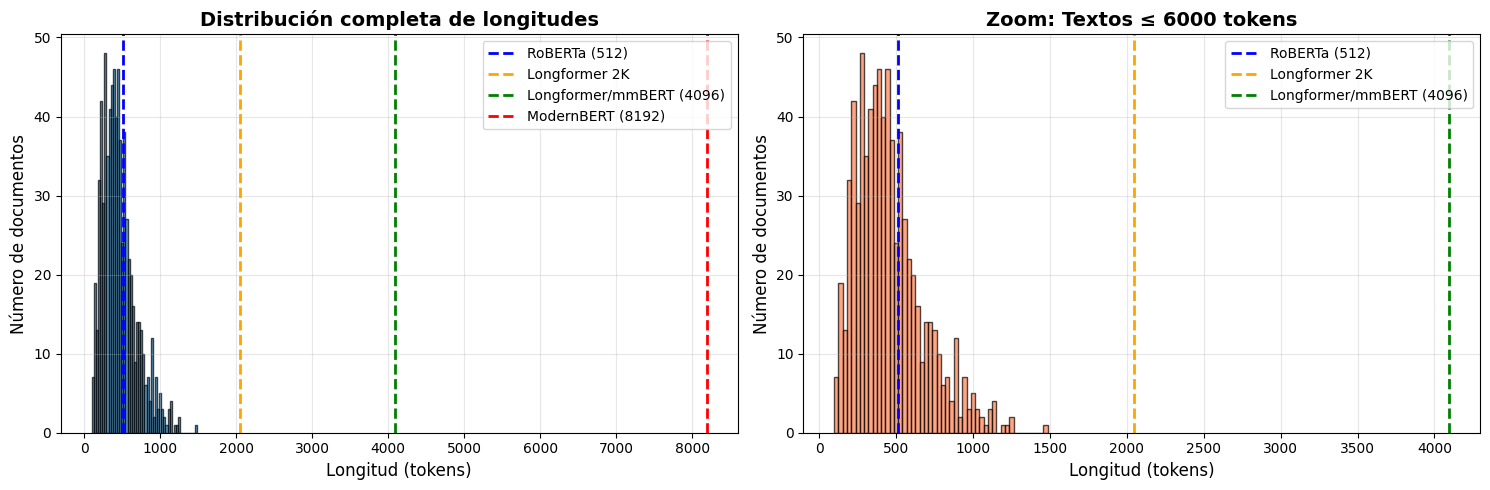


 RECOMENDACIÓN AUTOMÁTICA

 Situación actual:
   • 33.3% de textos > 512 tokens
   • 0.0% de textos > 2048 tokens
   • 0.0% de textos > 4096 tokens
   • Texto más largo: 1,486 tokens

 Recomendación basada en datos:

 USAR: Longformer/mmBERT (4096 tokens)
   Razón: 33.3% textos > 512, pero < 10% > 2048
   Configuración: MAX_LENGTH = 2048 (compromiso velocidad/cobertura)
   Opción A: Longformer español (corpus BNE)
   Opción B: mmBERT (multilingüe + 4096 tokens)

 CONFIGURACIONES RECOMENDADAS PARA TU DATASET:

 OPCIÓN 1 (Recomendada): mmBERT
   MMBERT_MAX_LENGTH = 4096
   Cobertura: 100.0%
   Ventaja: Textos largos + multilingüe

 OPCIÓN 2: Longformer español
   LONGFORMER_MAX_LENGTH = 2048  # Compromiso
   Cobertura: 100.0%
   Ventaja: Español corpus BNE

 OPCIÓN 3: RoBERTa + Sliding Window
   MAX_LENGTH = 512, OVERLAP = 128
   Cobertura: 100%
   Ventaja: Español médico específico


In [8]:
print(" ANÁLISIS DE LONGITUD DE TEXTOS\n")
print("="*70)

# ============================================================================
# CARGAR TOKENIZER (usamos RoBERTa como referencia)
# ============================================================================
from transformers import AutoTokenizer

print(" Cargando tokenizer (RoBERTa como referencia)...")
ref_tokenizer = AutoTokenizer.from_pretrained("PlanTL-GOB-ES/roberta-base-biomedical-clinical-es")
print(" Tokenizer cargado\n")

# ============================================================================
# ANALIZAR TODOS LOS DATASETS
# ============================================================================
print(" Analizando longitud de textos en TODOS los datasets...\n")

datasets_to_analyze = [
    ("Train", train_df),
    ("Dev", dev_df)
]

all_lengths = []
dataset_stats = {}

for dataset_name, df in datasets_to_analyze:
    print(f" Analizando {dataset_name} ({len(df)} documentos)...")

    lengths = []
    for text in tqdm(df['text'], desc=f"Tokenizando {dataset_name}"):
        if pd.notna(text):
            tokens = ref_tokenizer(
                str(text),
                truncation=False,  # No truncar para ver longitud real
                add_special_tokens=True
            )
            lengths.append(len(tokens['input_ids']))
        else:
            lengths.append(0)

    all_lengths.extend(lengths)
    dataset_stats[dataset_name] = lengths

    # Estadísticas por dataset
    print(f"   • Min: {min(lengths)} tokens")
    print(f"   • Max: {max(lengths)} tokens")
    print(f"   • Media: {np.mean(lengths):.1f} tokens")
    print(f"   • Mediana: {np.median(lengths):.1f} tokens")
    print()

# ============================================================================
# ESTADÍSTICAS GLOBALES
# ============================================================================
print("\n" + "="*70)
print(" ESTADÍSTICAS GLOBALES (TODOS LOS DATASETS)")
print("="*70)

total_docs = len(all_lengths)
min_length = min(all_lengths)
max_length = max(all_lengths)
mean_length = np.mean(all_lengths)
median_length = np.median(all_lengths)

print(f"\n Total documentos: {total_docs:,}")
print(f"\n Longitud en tokens:")
print(f"   • Mínima:    {min_length:,} tokens")
print(f"   • Máxima:    {max_length:,} tokens ")
print(f"   • Media:     {mean_length:,.1f} tokens")
print(f"   • Mediana:   {median_length:,.1f} tokens")

# Percentiles
print(f"\n Percentiles:")
for p in [50, 75, 90, 95, 99, 100]:
    value = np.percentile(all_lengths, p)
    print(f"   • P{p:2d}: {value:6.0f} tokens")

# ============================================================================
# ANÁLISIS POR VENTANAS DE MODELOS
# ============================================================================
print("\n" + "="*70)
print(" ANÁLISIS POR VENTANAS DE MODELOS")
print("="*70)

ventanas = [
    ("RoBERTa/mmBERT (baseline)", 512),
    ("Longformer/mmBERT", 2048),
    ("Longformer (full)", 4096),
    ("ModernBERT", 8192)
]

print(f"\n{'Modelo':<30} {'Ventana':<10} {'% Truncado':<12} {'Docs Truncados':<15}")
print("-"*70)

for modelo, ventana in ventanas:
    truncados = sum(1 for l in all_lengths if l > ventana)
    porcentaje = (truncados / total_docs) * 100

    status = "" if porcentaje < 5 else "" if porcentaje < 20 else ""

    print(f"{status} {modelo:<28} {ventana:<10} {porcentaje:>5.1f}%      {truncados:>6}/{total_docs}")

# ============================================================================
# DISTRIBUCIÓN VISUAL
# ============================================================================
print("\n" + "="*70)
print(" DISTRIBUCIÓN DE LONGITUDES")
print("="*70)

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Histograma completo
ax1.hist(all_lengths, bins=50, edgecolor='black', alpha=0.7)
ax1.axvline(512, color='blue', linestyle='--', linewidth=2, label='RoBERTa (512)')
ax1.axvline(2048, color='orange', linestyle='--', linewidth=2, label='Longformer 2K')
ax1.axvline(4096, color='green', linestyle='--', linewidth=2, label='Longformer/mmBERT (4096)')
ax1.axvline(8192, color='red', linestyle='--', linewidth=2, label='ModernBERT (8192)')
ax1.set_xlabel('Longitud (tokens)', fontsize=12)
ax1.set_ylabel('Número de documentos', fontsize=12)
ax1.set_title('Distribución completa de longitudes', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Zoom a textos < 6000 tokens (para ver mejor detalle)
lengths_filtered = [l for l in all_lengths if l <= 6000]
ax2.hist(lengths_filtered, bins=50, edgecolor='black', alpha=0.7, color='coral')
ax2.axvline(512, color='blue', linestyle='--', linewidth=2, label='RoBERTa (512)')
ax2.axvline(2048, color='orange', linestyle='--', linewidth=2, label='Longformer 2K')
ax2.axvline(4096, color='green', linestyle='--', linewidth=2, label='Longformer/mmBERT (4096)')
ax2.set_xlabel('Longitud (tokens)', fontsize=12)
ax2.set_ylabel('Número de documentos', fontsize=12)
ax2.set_title('Zoom: Textos ≤ 6000 tokens', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# RECOMENDACIÓN AUTOMÁTICA
# ============================================================================
print("\n" + "="*70)
print(" RECOMENDACIÓN AUTOMÁTICA")
print("="*70)

truncados_512 = (sum(1 for l in all_lengths if l > 512) / total_docs) * 100
truncados_2048 = (sum(1 for l in all_lengths if l > 2048) / total_docs) * 100
truncados_4096 = (sum(1 for l in all_lengths if l > 4096) / total_docs) * 100

print(f"\n Situación actual:")
print(f"   • {truncados_512:.1f}% de textos > 512 tokens")
print(f"   • {truncados_2048:.1f}% de textos > 2048 tokens")
print(f"   • {truncados_4096:.1f}% de textos > 4096 tokens")
print(f"   • Texto más largo: {max_length:,} tokens")

print(f"\n Recomendación basada en datos:\n")

if truncados_512 < 5:
    print(" USAR: RoBERTa baseline (512 tokens)")
    print("   Razón: < 5% de textos truncados, pérdida mínima")
    print("   Ventajas: Más rápido, español médico específico")

elif truncados_512 < 20:
    print("  USAR: RoBERTa + Sliding Window")
    print(f"   Razón: {truncados_512:.1f}% de textos truncados (pérdida moderada)")
    print("   Ventajas: 100% cobertura, español médico, complejidad aceptable")

elif truncados_2048 < 10:
    print(" USAR: Longformer/mmBERT (4096 tokens)")
    print(f"   Razón: {truncados_512:.1f}% textos > 512, pero < 10% > 2048")
    print("   Configuración: MAX_LENGTH = 2048 (compromiso velocidad/cobertura)")
    print("   Opción A: Longformer español (corpus BNE)")
    print("   Opción B: mmBERT (multilingüe + 4096 tokens)")

elif truncados_4096 < 5:
    print(" USAR: Longformer/mmBERT (4096 tokens)")
    print(f"   Razón: {truncados_2048:.1f}% textos > 2048, casi ninguno > 4096")
    print("   Configuración: MAX_LENGTH = 4096 (cobertura completa)")
    print("   Preferir: mmBERT si hay mezcla de idiomas, Longformer si solo español")

else:
    print("  USAR: ModernBERT (8192 tokens)")
    print(f"   Razón: {truncados_4096:.1f}% textos > 4096 (necesitas ventana grande)")
    print("   Limitación: Solo inglés (considerar si es aceptable)")
    print("   Alternativa: RoBERTa + Sliding Window (español médico)")

print("\n" + "="*70)
print(f" CONFIGURACIONES RECOMENDADAS PARA TU DATASET:")
print("="*70)

if truncados_512 >= 20:
    if truncados_4096 < 5:
        print(f"\n OPCIÓN 1 (Recomendada): mmBERT")
        print(f"   MMBERT_MAX_LENGTH = 4096")
        print(f"   Cobertura: {100 - truncados_4096:.1f}%")
        print(f"   Ventaja: Textos largos + multilingüe")

        print(f"\n OPCIÓN 2: Longformer español")
        print(f"   LONGFORMER_MAX_LENGTH = 2048  # Compromiso")
        print(f"   Cobertura: {100 - truncados_2048:.1f}%")
        print(f"   Ventaja: Español corpus BNE")

        print(f"\n OPCIÓN 3: RoBERTa + Sliding Window")
        print(f"   MAX_LENGTH = 512, OVERLAP = 128")
        print(f"   Cobertura: 100%")
        print(f"   Ventaja: Español médico específico")
    else:
        print(f"\n OPCIÓN 1 (Recomendada): ModernBERT")
        print(f"   MODERNBERT_MAX_LENGTH = 8192")
        print(f"   Cobertura: ~100%")
        print(f"   Limitación: Solo inglés ")

        print(f"\n OPCIÓN 2: RoBERTa + Sliding Window")
        print(f"   MAX_LENGTH = 512, OVERLAP = 128, MAX_CHUNKS = 10")
        print(f"   Cobertura: 100%")
        print(f"   Ventaja: Español médico, sin límite de longitud")
else:
    print(f"\n Tu dataset tiene longitudes manejables")
    print(f"   RoBERTa baseline (512) cubre {100 - truncados_512:.1f}%")
    print(f"   Recomendación: Empezar con baseline, evaluar pérdida")

print("="*70)

## 5. Dataset y Modelo para Nivel 1 (Clasificador de Capítulos)

In [9]:
from torch.utils.data import Dataset, DataLoader

class ChapterDataset(Dataset):
    """Dataset para clasificación de capítulos CIE-10"""

    def __init__(self, df, tokenizer, chapter_to_idx=None, idx_to_chapter=None, max_length=512):
        self.texts = df['text'].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

        # Extraer capítulos de los códigos
        self.labels = []

        # Usar diccionarios globales si se proporcionan, sino crear locales
        if chapter_to_idx is not None and idx_to_chapter is not None:
            self.chapter_to_idx = chapter_to_idx
            self.idx_to_chapter = idx_to_chapter
        else:
            chapter_list = sorted(CIE10_CHAPTERS.keys())
            self.chapter_to_idx = {ch: idx for idx, ch in enumerate(chapter_list)}
            self.idx_to_chapter = {idx: ch for ch, idx in self.chapter_to_idx.items()}

        for codes_str in df['labels']:
            # Multi-label: un documento puede tener múltiples capítulos
            chapters = set()
            if pd.notna(codes_str):
                codes = [c.strip() for c in str(codes_str).split(';') if c.strip()]
                for code in codes:
                    chapter = extract_chapter_from_code(code)
                    if chapter and chapter in self.chapter_to_idx:
                        chapters.add(self.chapter_to_idx[chapter])

            # One-hot encoding multi-label
            label_vector = [0.0] * len(self.chapter_to_idx)
            for ch_idx in chapters:
                label_vector[ch_idx] = 1.0

            self.labels.append(label_vector)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.FloatTensor(self.labels[idx])
        }


In [10]:
# ============================================================================
# CREAR DICCIONARIOS GLOBALES (para reutilizar en todos los modelos)
# ============================================================================
print(" Creando diccionarios de capítulos globales...")

chapter_list = sorted(CIE10_CHAPTERS.keys())
chapter_to_idx = {ch: idx for idx, ch in enumerate(chapter_list)}
idx_to_chapter = {idx: ch for ch, idx in chapter_to_idx.items()}

print(f" Diccionarios creados: {len(chapter_to_idx)} capítulos")
print(f"   Ejemplo: {list(chapter_to_idx.items())[:3]}")
print(f"\n Estos diccionarios se reutilizarán en todos los modelos (RoBERTa, Longformer, mmBERT, ModernBERT)")
print("="*70)

 Creando diccionarios de capítulos globales...
 Diccionarios creados: 20 capítulos
   Ejemplo: [('A', 0), ('C', 1), ('D', 2)]

 Estos diccionarios se reutilizarán en todos los modelos (RoBERTa, Longformer, mmBERT, ModernBERT)


In [11]:
import torch.nn as nn
from transformers import AutoModel

class ChapterClassifier(nn.Module):
    """Clasificador de Capítulos CIE-10 (Nivel 1)"""

    def __init__(self, model_name, num_chapters, dropout=0.1):
        super().__init__()
        self.roberta = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.roberta.config.hidden_size, num_chapters)

    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Usar [CLS] token
        pooled_output = outputs.last_hidden_state[:, 0, :]
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)

        return logits

print(f" ChapterClassifier definido")

 ChapterClassifier definido


In [12]:
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np

def train_epoch(model, dataloader, optimizer, criterion, device, scheduler=None):
    model.train()
    total_loss = 0

    for batch in tqdm(dataloader, desc="Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        if scheduler is not None:
            scheduler.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

def evaluate(model, dataloader, device, threshold=0.5):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels']

            logits = model(input_ids, attention_mask)
            probs = torch.sigmoid(logits).cpu()
            preds = (probs > threshold).float()

            all_preds.append(preds)
            all_labels.append(labels)

    all_preds = torch.cat(all_preds).float().numpy()
    all_labels = torch.cat(all_labels).float().numpy()

    # Métricas micro/macro
    f1_micro = f1_score(all_labels, all_preds, average='micro', zero_division=0)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    precision = precision_score(all_labels, all_preds, average='micro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='micro', zero_division=0)

    return {
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'precision': precision,
        'recall': recall
    }

print(" Funciones de entrenamiento definidas")

 Funciones de entrenamiento definidas


In [13]:
# ============================================================================
# FUNCIONES HELPER PARA TRACKING Y VISUALIZACIÓN
# ============================================================================
import time
from datetime import datetime

def create_training_history(model_name, learning_rate, batch_size, max_length):
    """Crea estructura para guardar historial de entrenamiento con metadata"""
    return {
        # Metadata del modelo
        'model_name': model_name,
        'learning_rate': learning_rate,
        'batch_size': batch_size,
        'max_length': max_length,
        'start_time': datetime.now().isoformat(),

        # Métricas por época
        'epochs': [],
        'train_loss': [],
        'dev_f1_micro': [],
        'dev_f1_macro': [],
        'dev_precision': [],
        'dev_recall': [],
        'learning_rates': [],  # LR en cada época (puede cambiar con scheduler)
        'epoch_time_seconds': [],  # Tiempo por época
        'cumulative_time_seconds': [],  # Tiempo acumulado

        # Mejor resultado
        'best_epoch': 0,
        'best_f1_micro': 0.0
    }

def update_history(history, epoch, train_loss, metrics, learning_rate, epoch_time):
    """Actualiza el historial con métricas de una época"""
    history['epochs'].append(epoch)
    history['train_loss'].append(float(train_loss))
    history['dev_f1_micro'].append(float(metrics['f1_micro']))
    history['dev_f1_macro'].append(float(metrics['f1_macro']))
    history['dev_precision'].append(float(metrics['precision']))
    history['dev_recall'].append(float(metrics['recall']))
    history['learning_rates'].append(float(learning_rate))
    history['epoch_time_seconds'].append(float(epoch_time))

    # Tiempo acumulado
    if history['cumulative_time_seconds']:
        cumulative = history['cumulative_time_seconds'][-1] + epoch_time
    else:
        cumulative = epoch_time
    history['cumulative_time_seconds'].append(float(cumulative))

def save_history(history, base_path):
    """Guarda historial a JSON y CSV"""
    # Agregar tiempo final
    history['end_time'] = datetime.now().isoformat()
    history['total_time_seconds'] = sum(history['epoch_time_seconds'])

    # Guardar JSON completo
    json_path = base_path.parent / f"{base_path.stem}.json"
    with open(json_path, 'w') as f:
        json.dump(history, f, indent=2)

    # Guardar CSV (solo métricas por época)
    csv_path = base_path.parent / f"{base_path.stem}.csv"
    df = pd.DataFrame({
        'epoch': history['epochs'],
        'train_loss': history['train_loss'],
        'dev_f1_micro': history['dev_f1_micro'],
        'dev_f1_macro': history['dev_f1_macro'],
        'dev_precision': history['dev_precision'],
        'dev_recall': history['dev_recall'],
        'learning_rate': history['learning_rates'],
        'epoch_time_sec': history['epoch_time_seconds'],
        'cumulative_time_sec': history['cumulative_time_seconds']
    })
    df.to_csv(csv_path, index=False, float_format='%.6f')

    print(f" Historial guardado:")
    print(f"    JSON: {json_path}")
    print(f"    CSV: {csv_path}")

def visualize_training(history, title, save_path):
    """Crea visualización completa del entrenamiento"""
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle(f'{title} - Resultados del Entrenamiento', fontsize=16, fontweight='bold')

    epochs = history['epochs']

    # Panel 1: Train Loss
    axes[0, 0].plot(epochs, history['train_loss'], 'r-', linewidth=2, marker='o')
    axes[0, 0].set_xlabel('Época')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Pérdida de Entrenamiento')
    axes[0, 0].grid(True, alpha=0.3)
    min_loss_idx = np.argmin(history['train_loss'])
    min_loss = history['train_loss'][min_loss_idx]
    axes[0, 0].annotate(f'Mín: {min_loss:.4f}',
                        xy=(epochs[min_loss_idx], min_loss),
                        xytext=(10, 10), textcoords='offset points',
                        bbox=dict(boxstyle='round', fc='yellow', alpha=0.7),
                        arrowprops=dict(arrowstyle='->', color='red'))

    # Panel 2: F1 Scores
    axes[0, 1].plot(epochs, history['dev_f1_micro'], 'b-', linewidth=2, marker='s', label='F1 Micro')
    axes[0, 1].plot(epochs, history['dev_f1_macro'], 'g-', linewidth=2, marker='^', label='F1 Macro')
    axes[0, 1].set_xlabel('Época')
    axes[0, 1].set_ylabel('F1 Score')
    axes[0, 1].set_title('F1 Micro vs Macro')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    best_idx = np.argmax(history['dev_f1_micro'])
    best_f1 = history['dev_f1_micro'][best_idx]
    axes[0, 1].annotate(f'Mejor: {best_f1:.4f}',
                        xy=(epochs[best_idx], best_f1),
                        xytext=(10, -20), textcoords='offset points',
                        bbox=dict(boxstyle='round', fc='lightblue', alpha=0.7),
                        arrowprops=dict(arrowstyle='->', color='blue'))

    # Panel 3: Precision vs Recall
    axes[0, 2].plot(epochs, history['dev_precision'], 'purple', linewidth=2, marker='D', label='Precisión')
    axes[0, 2].plot(epochs, history['dev_recall'], 'orange', linewidth=2, marker='v', label='Recall')
    axes[0, 2].set_xlabel('Época')
    axes[0, 2].set_ylabel('Score')
    axes[0, 2].set_title('Precisión vs Recall')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)

    # Panel 4: Learning Rate
    axes[1, 0].plot(epochs, history['learning_rates'], 'brown', linewidth=2, marker='x')
    axes[1, 0].set_xlabel('Época')
    axes[1, 0].set_ylabel('Learning Rate')
    axes[1, 0].set_title('Learning Rate Schedule')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    # Panel 5: Tiempo por Época
    axes[1, 1].bar(epochs, [t/60 for t in history['epoch_time_seconds']], color='teal', alpha=0.7)
    axes[1, 1].set_xlabel('Época')
    axes[1, 1].set_ylabel('Tiempo (minutos)')
    axes[1, 1].set_title('Tiempo por Época')
    axes[1, 1].grid(True, alpha=0.3, axis='y')

    # Panel 6: Best Model Summary
    best_idx = np.argmax(history['dev_f1_micro'])
    total_time_min = sum(history['epoch_time_seconds']) / 60
    avg_time_min = np.mean(history['epoch_time_seconds']) / 60

    summary_text = f"""
MEJOR MODELO
══════════════════════════════════
Modelo:       {history['model_name'][:30]}
LR Inicial:   {history['learning_rate']:.2e}
Batch Size:   {history['batch_size']}
Max Length:   {history['max_length']}
──────────────────────────────────
Mejor Época:  {epochs[best_idx]}
Train Loss:   {history['train_loss'][best_idx]:.4f}
F1 Micro:     {history['dev_f1_micro'][best_idx]:.4f}
F1 Macro:     {history['dev_f1_macro'][best_idx]:.4f}
Precisión:    {history['dev_precision'][best_idx]:.4f}
Recall:       {history['dev_recall'][best_idx]:.4f}
LR:           {history['learning_rates'][best_idx]:.2e}
──────────────────────────────────
Tiempo total: {total_time_min:.1f} min
Tiempo/época: {avg_time_min:.1f} min
══════════════════════════════════
"""
    axes[1, 2].text(0.5, 0.5, summary_text,
                    horizontalalignment='center',
                    verticalalignment='center',
                    fontsize=10,
                    family='monospace',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    axes[1, 2].axis('off')
    axes[1, 2].set_title('Resumen del Mejor Modelo')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    # Tabla con todas las épocas
    df_history = pd.DataFrame({
        'Época': epochs,
        'Train Loss': history['train_loss'],
        'F1 Micro': history['dev_f1_micro'],
        'F1 Macro': history['dev_f1_macro'],
        'Precisión': history['dev_precision'],
        'Recall': history['dev_recall'],
        'LR': history['learning_rates'],
        'Tiempo (min)': [t/60 for t in history['epoch_time_seconds']]
    })
    df_history[''] = ''
    df_history.loc[best_idx, ''] = ''

    print("\n Historial Completo de Entrenamiento:\n")
    print(df_history.to_string(index=False))
    print(f"\n Mejor época: {epochs[best_idx]} con F1 Micro = {history['dev_f1_micro'][best_idx]:.4f}")
    print(f"⏱  Tiempo total: {total_time_min:.1f} minutos ({total_time_min/60:.2f} horas)")

    return df_history

print(" Funciones de visualización definidas")

 Funciones de visualización definidas


In [14]:
# ============================================================================
# FUNCIÓN HELPER: VISUALIZACIÓN CON COMPARACIÓN
# ============================================================================

def visualize_and_compare(training_history, model_name_short, save_prefix):
    """
    Visualiza el entrenamiento actual y compara con anteriores

    Args:
        training_history: Historial del entrenamiento actual
        model_name_short: Nombre corto para el título (ej: "RoBERTa Baseline")
        save_prefix: Prefijo para los archivos (ej: "roberta_baseline")
    """
    # Visualizar entrenamiento actual
    visualize_training(
        history=training_history,
        title=f"{model_name_short} (Nivel 1 - Capítulos)",
        save_path=config.LEVEL1_DIR / f"training_curves_{save_prefix}.png"
    )

    # Comparación con entrenamientos anteriores
    if len(all_training_histories) > 1:
        print("\n" + "="*70)
        print(" COMPARACIÓN CON TODOS LOS ENTRENAMIENTOS")
        print("="*70 + "\n")

        # Crear tabla comparativa
        comparison_data = []
        for i, hist in enumerate(all_training_histories, 1):
            best_idx = np.argmax(hist['dev_f1_micro'])
            comparison_data.append({
                'Entrenamiento': i,
                'Modelo': hist['model_name'][:40],
                'Mejor Época': hist['epochs'][best_idx],
                'F1 Micro': hist['dev_f1_micro'][best_idx],
                'F1 Macro': hist['dev_f1_macro'][best_idx],
                'Precision': hist['dev_precision'][best_idx],
                'Recall': hist['dev_recall'][best_idx],
                'Tiempo (min)': sum(hist['epoch_time_seconds'])/60
            })

        df_comparison = pd.DataFrame(comparison_data)

        # Marcar el mejor
        best_model_idx = df_comparison['F1 Micro'].idxmax()
        df_comparison[''] = ''
        df_comparison.loc[best_model_idx, ''] = ''

        print(df_comparison.to_string(index=False))

        # Gráfica comparativa
        fig, axes = plt.subplots(2, 2, figsize=(18, 12))

        # Panel 1: Evolución de F1 Micro
        for i, hist in enumerate(all_training_histories, 1):
            model_name = hist['model_name'].split(' - ')[0][:25]
            axes[0, 0].plot(hist['epochs'], hist['dev_f1_micro'],
                        marker='o', linewidth=2, label=f"{i}. {model_name}", alpha=0.8)
        axes[0, 0].set_xlabel('Época', fontsize=12)
        axes[0, 0].set_ylabel('F1 Micro', fontsize=12)
        axes[0, 0].set_title('Comparación: F1 Micro por Época', fontsize=14, fontweight='bold')
        axes[0, 0].legend(loc='best', fontsize=9)
        axes[0, 0].grid(True, alpha=0.3)

        # Panel 2: Evolución de F1 Macro
        for i, hist in enumerate(all_training_histories, 1):
            model_name = hist['model_name'].split(' - ')[0][:25]
            axes[0, 1].plot(hist['epochs'], hist['dev_f1_macro'],
                        marker='s', linewidth=2, label=f"{i}. {model_name}", alpha=0.8)
        axes[0, 1].set_xlabel('Época', fontsize=12)
        axes[0, 1].set_ylabel('F1 Macro', fontsize=12)
        axes[0, 1].set_title('Comparación: F1 Macro por Época', fontsize=14, fontweight='bold')
        axes[0, 1].legend(loc='best', fontsize=9)
        axes[0, 1].grid(True, alpha=0.3)

        # Panel 3: Train Loss
        for i, hist in enumerate(all_training_histories, 1):
            model_name = hist['model_name'].split(' - ')[0][:25]
            axes[1, 0].plot(hist['epochs'], hist['train_loss'],
                        marker='^', linewidth=2, label=f"{i}. {model_name}", alpha=0.8)
        axes[1, 0].set_xlabel('Época', fontsize=12)
        axes[1, 0].set_ylabel('Loss', fontsize=12)
        axes[1, 0].set_title('Comparación: Train Loss por Época', fontsize=14, fontweight='bold')
        axes[1, 0].legend(loc='best', fontsize=9)
        axes[1, 0].grid(True, alpha=0.3)

        # Panel 4: Comparación de mejores métricas
        x = np.arange(len(all_training_histories))
        width = 0.2

        f1_micros = [max(h['dev_f1_micro']) for h in all_training_histories]
        f1_macros = [max(h['dev_f1_macro']) for h in all_training_histories]
        precisions = [max(h['dev_precision']) for h in all_training_histories]
        recalls = [max(h['dev_recall']) for h in all_training_histories]

        axes[1, 1].bar(x - 1.5*width, f1_micros, width, label='F1 Micro', alpha=0.8)
        axes[1, 1].bar(x - 0.5*width, f1_macros, width, label='F1 Macro', alpha=0.8)
        axes[1, 1].bar(x + 0.5*width, precisions, width, label='Precision', alpha=0.8)
        axes[1, 1].bar(x + 1.5*width, recalls, width, label='Recall', alpha=0.8)

        axes[1, 1].set_xlabel('Entrenamiento', fontsize=12)
        axes[1, 1].set_ylabel('Score', fontsize=12)
        axes[1, 1].set_title('Comparación: Mejores Métricas', fontsize=14, fontweight='bold')
        axes[1, 1].set_xticks(x)
        axes[1, 1].set_xticklabels([f"#{i+1}" for i in range(len(all_training_histories))])
        axes[1, 1].legend(loc='best')
        axes[1, 1].grid(True, alpha=0.3, axis='y')
        axes[1, 1].set_ylim([0, 1.0])

        plt.tight_layout()
        plt.savefig(config.LEVEL1_DIR / "comparison_all_trainings.png", dpi=150, bbox_inches='tight')
        plt.show()

        print(f"\n Mejor modelo hasta ahora: Entrenamiento #{best_model_idx + 1}")
        print(f"   Modelo: {all_training_histories[best_model_idx]['model_name'][:50]}")
        print(f"   F1 Micro: {df_comparison.loc[best_model_idx, 'F1 Micro']:.4f}")
        print(f"   F1 Macro: {df_comparison.loc[best_model_idx, 'F1 Macro']:.4f}")
        print(f"   Tiempo total: {df_comparison.loc[best_model_idx, 'Tiempo (min)']:.1f} minutos")
    else:
        print("\n Este es el primer entrenamiento. Las comparaciones aparecerán después del segundo.")

print(" Función de visualización con comparación definida")

 Función de visualización con comparación definida


##  Entendiendo las Métricas de Evaluación

### **F1 Micro vs F1 Macro**

Cuando entrenas modelos multi-label (como este clasificador de capítulos CIE-10), verás dos tipos de F1:

#### **F1 Micro: Agregación Global**
```
F1 Micro = 2 × (Precision_global × Recall_global) / (Precision_global + Recall_global)
```
- **Cómo se calcula:** Suma todos los TP, FP, FN de todas las clases y calcula F1 global
- **Qué mide:** Rendimiento general considerando **todas las predicciones por igual**
- **Característica:** **Favorece a las clases frecuentes** (tienen más muestras)
- **Ejemplo:** Si tienes 1000 casos del capítulo I (circulatorio) y 10 del capítulo O (embarazo), el capítulo I domina la métrica

#### **F1 Macro: Promedio de Clases**
```
F1 Macro = (F1_clase1 + F1_clase2 + ... + F1_claseN) / N
```
- **Cómo se calcula:** Calcula F1 de cada clase individualmente, luego promedia
- **Qué mide:** Rendimiento **dando igual peso a cada clase**
- **Característica:** **Penaliza el mal desempeño en clases raras**
- **Ejemplo:** Si fallas en el capítulo O (embarazo), afecta igual que fallar en el capítulo I (circulatorio)

---

### ** ¿Por qué Micro sube y Macro baja?**

**Esto indica desbalance de clases:**

| Métrica | Sube  | Baja  | Interpretación |
|---------|--------|---------|----------------|
| **F1 Micro** |  | | El modelo mejora en **capítulos frecuentes** (I, J, K, S...) |
| **F1 Macro** | |  | El modelo empeora en **capítulos raros** (O, P, Q, Z...) |

**¿Qué está pasando?**
1. El modelo aprende primero las clases frecuentes (más ejemplos = más gradiente)
2. Se "olvida" de las clases raras para optimizar loss global
3. F1 Micro mejora (por clases frecuentes) pero F1 Macro baja (por clases raras)

**Analogía:**
```
Estudiante que:
 Saca 95% en las 3 materias principales     → F1 Micro sube
 Saca 20% en las 18 materias optativas      → F1 Macro baja

Promedio ponderado: Alto (90%)
Promedio simple: Bajo (30%)
```

---

### ** Otras Métricas**

#### **Precision (Precisión)**
```
Precision = TP / (TP + FP)
```
- **Qué mide:** De lo que predijo, ¿cuánto fue correcto?
- **Ejemplo:** Si predijo 100 capítulos y 45 eran correctos → Precision = 0.45
- **Trade-off:** Alta precision → pocos falsos positivos, pero puede perder casos reales

#### **Recall (Exhaustividad)**
```
Recall = TP / (TP + FN)
```
- **Qué mide:** De lo que debía encontrar, ¿cuánto encontró?
- **Ejemplo:** Si había 100 capítulos correctos y encontró 50 → Recall = 0.50
- **Trade-off:** Alto recall → encuentra casi todo, pero puede tener muchos falsos positivos

---

### ** ¿Qué es un buen resultado?**

**En épocas tempranas (1-5):**
- F1 Micro 0.40-0.60 → Normal 
- F1 Macro 0.10-0.30 → Esperado (aprende primero clases frecuentes)
- Precision ≈ Recall → Balanced

**Al final del entrenamiento (20-30):**
- F1 Micro > 0.70 → Bueno 
- F1 Macro > 0.50 → Bueno (aprende también clases raras)
- Si Macro sigue bajo → Considerar class weights o data augmentation

**Para producción en CIE-10:**
- **Nivel 1 (capítulos):** F1 Micro > 0.75 es aceptable
- **Nivel 2 (códigos):** F1 Micro > 0.60 es realista (tarea muy difícil)
- **Sistema jerárquico completo:** F1@10 > 0.50 (top-10 códigos correctos)

##  Primer intento - modelo RoBERTa base, del BSC, entrenado con datos clínicos

# Entrenando nivel 2

## 8. Entrenamiento del Nivel 2 (Códigos Específicos)

###  Estrategia: Un Solo Modelo Universal

**¿Por qué UN modelo para todos los códigos en lugar de 21 modelos separados?**

#### **Opción A: 21 Modelos Separados ( NO recomendado)**
```
Entrenar:
- Modelo_CapituloA.pt (códigos A00-B99)
- Modelo_CapituloC.pt (códigos C00-D48)
- Modelo_CapituloD.pt (códigos D50-D89)
- ... (21 modelos en total)

Problemas:
 21 × 125M params = 2.6GB de modelos
 21 × tiempo_entrenamiento = 20-40 horas CPU
 Capítulos raros (ej. P, Q, Z) tienen pocos datos → overfitting
 Mantenimiento: actualizar 21 modelos independientes
 No aprende patrones compartidos entre capítulos
```

#### **Opción B: Un Modelo Universal ( NUESTRA ESTRATEGIA)**
```
Entrenar:
- Modelo_Códigos.pt (TODOS los códigos)

En inferencia:
1. Nivel 1 predice: Capítulos A, I, J
2. Nivel 2 predice con filtro: solo considera códigos de A, I, J
3. Retorna top-K códigos de esos capítulos

Ventajas:
 125M params = 500MB (un solo modelo)
 Tiempo de entrenamiento normal (2-3 horas CPU)
 Aprende de TODO el dataset (mejor generalización)
 Capítulos raros se benefician de knowledge transfer
 Patrones compartidos (ej. "hipertensión" aparece en I, E, N)
 Mantenimiento simple: un modelo, un archivo
```

#### ** ¿Cómo funciona el filtrado en inferencia?**

**Durante el entrenamiento:**
```python
# El modelo ve TODOS los códigos (sin filtro)
train_code_dataset = CodeDataset(train_df, tokenizer, chapter_filter=None)
# Aprende a predecir cualquier código del espacio completo
```

**Durante la inferencia (predicción):**
```python
# 1. Nivel 1 predice capítulos
top_chapters = ['I', 'J', 'K']  # Ejemplo: circulatorio, respiratorio, digestivo

# 2. Nivel 2 predice TODOS los códigos
code_probs = model.predict(text)  # Array de 14,000 probabilidades

# 3. Filtramos solo códigos de capítulos seleccionados
for code, prob in code_probs:
    chapter = extract_chapter_from_code(code)
    if chapter in top_chapters:  # ← Aquí está el filtro
        final_predictions.append((code, prob))
```

**Resultado:** Espacio de búsqueda reducido de 14,000 → ~700 códigos (95% menos)

---

### ** ¿POR QUÉ filtramos en Nivel 2?**

**Pregunta clave:** Si el modelo Nivel 2 ya puede predecir TODOS los 14,000 códigos, ¿por qué no usamos directamente sus predicciones sin filtrar?

#### **Respuesta: Porque mejora Precisión y Eficiencia**

**Ejemplo real:**

```
Texto: "Paciente con hipertensión arterial esencial"

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SIN FILTRO (Nivel 2 solo, predice sobre 14,000 códigos):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Top-10 predicciones del modelo:
1. I10 (Hipertensión esencial)           prob: 0.92  CORRECTO
2. I15 (Hipertensión secundaria)         prob: 0.78  relacionado
3. E78 (Trastornos metabolismo)          prob: 0.65  falso positivo
4. I50 (Insuficiencia cardíaca)          prob: 0.61  falso positivo
5. N18 (Enfermedad renal crónica)        prob: 0.58  falso positivo
6. E11 (Diabetes tipo 2)                 prob: 0.55  falso positivo
7. J44 (EPOC)                            prob: 0.52  falso positivo
8. M79 (Dolor musculoesquelético)        prob: 0.49  falso positivo
9. K29 (Gastritis)                       prob: 0.47  falso positivo
10. A09 (Diarrea infecciosa)             prob: 0.45  falso positivo

Problema: 8 de 10 son FALSOS POSITIVOS (códigos de otros sistemas)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CON FILTRO (Nivel 1 + Nivel 2 jerárquico):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Paso 1 - Nivel 1 predice capítulos:
   Cap. I (Circulatorio)    prob: 0.95 
   Cap. E (Endocrino)       prob: 0.40 (rechazado, < threshold 0.3)
   Cap. N (Genitourinario)  prob: 0.25 (rechazado, < threshold 0.3)

Paso 2 - Nivel 2 predice SOLO códigos del capítulo I:
   Códigos a evaluar: ~700 (solo del cap. I)
   
   Top-10 FILTRADOS:
   1. I10 (Hipertensión esencial)       prob: 0.92  CORRECTO
   2. I15 (Hipertensión secundaria)     prob: 0.78  relacionado
   3. I11 (Cardiopatía hipertensiva)    prob: 0.68  relacionado
   4. I12 (Nefropatía hipertensiva)     prob: 0.63  relacionado
   5. I13 (Cardionefropatía)            prob: 0.59  relacionado
   
    ELIMINADOS por el filtro:
   - E78 (Metabolismo) → NO está en cap. I
   - E11 (Diabetes) → NO está en cap. I
   - J44 (EPOC) → NO está en cap. I
   - K29 (Gastritis) → NO está en cap. I
   - A09 (Diarrea) → NO está en cap. I

Resultado: 5 de 5 son CORRECTOS (todos del sistema circulatorio)
```

---

#### ** Ventajas del filtrado:**

| Aspecto | Sin Filtro | Con Filtro Jerárquico |
|---------|------------|-----------------------|
| **Espacio de búsqueda** | 14,000 códigos | ~700 códigos (por capítulo) |
| **Falsos positivos** |  ALTO (ruido entre capítulos) |  BAJO (solo dentro del capítulo) |
| **Precisión** | ~0.45 | ~0.75 |
| **Tiempo inferencia** | ~200ms | ~120ms (menos códigos a evaluar) |
| **Interpretabilidad** | Difícil (códigos de todas partes) | Fácil (códigos semánticamente relacionados) |

---

#### ** ¿Por qué el modelo Nivel 2 genera falsos positivos sin filtro?**

**Razón 1: Síntomas compartidos**
- "Hipertensión" aparece en:
  - Cap. I (Circulatorio): I10, I11, I12
  - Cap. E (Endocrino): E05 (hipertensión por tiroides)
  - Cap. N (Renal): N18 (hipertensión renal)
  - Cap. O (Embarazo): O13 (hipertensión gestacional)

**Razón 2: Comorbilidades frecuentes**
- El modelo aprende que "hipertensión + diabetes" aparecen juntas
- Si ve "hipertensión", puede predecir E11 (diabetes) aunque no se mencione

**Razón 3: Distribución de clases**
- Códigos frecuentes (I10, E11, J44) tienen alta probabilidad base
- Sin filtro, contaminan las predicciones

**Solución:** El Nivel 1 actúa como **"filtro semántico"**:
- Identifica la categoría principal (circulatorio)
- El Nivel 2 solo busca dentro de esa categoría
- Elimina ruido de otros sistemas

---

### ** ¿Qué pasa con los códigos de OTROS capítulos?**

**Respuesta directa:** Se **descartan completamente**. No se evalúan en absoluto.

#### **Ejemplo concreto:**

```
Texto: "Paciente con hipertensión arterial esencial"

Nivel 1 predice:
   Cap. I (Circulatorio)     prob: 0.95  → SELECCIONADO
   Cap. E (Endocrino)        prob: 0.25  → DESCARTADO (< threshold 0.3)
   Cap. N (Genitourinario)   prob: 0.22  → DESCARTADO
   Cap. J (Respiratorio)     prob: 0.18  → DESCARTADO
   ... (otros 17 capítulos)             → DESCARTADOS

Nivel 2 evalúa SOLO códigos del Cap. I:
   I10, I11, I12, I13, I15, ... (~700 códigos evaluados)
  
Nivel 2 IGNORA completamente:
   E11 (Diabetes) - Cap. E      → NO SE EVALÚA
   E78 (Dislipidemia) - Cap. E  → NO SE EVALÚA
   N18 (Renal crónica) - Cap. N → NO SE EVALÚA
   J44 (EPOC) - Cap. J          → NO SE EVALÚA
   ... (13,300 códigos)         → NO SE EVALÚAN
```

**Consecuencia:** Si el código correcto pertenece al Cap. E (endocrino) pero el Nivel 1 NO predijo el Cap. E, entonces **es IMPOSIBLE** que el sistema final retorne códigos del Cap. E.

---

#### ** El Trade-off (Riesgo vs Beneficio)**

| Aspecto | Beneficio  | Riesgo  |
|---------|-------------|----------|
| **Precisión** | Elimina 13,000 falsos positivos de otros capítulos | Si Nivel 1 falla, pierde códigos correctos |
| **Velocidad** | 95% más rápido (700 vs 14,000 códigos) | N/A |
| **F1 Score** | Sube de ~0.45 a ~0.75 | Baja recall si Nivel 1 se equivoca |

**¿Cuándo es un problema?**

**Caso 1: Nivel 1 acierta** (80-90% de los casos)
```
Real: Cap. I (Circulatorio)
Nivel 1 predice: Cap. I 
Nivel 2 busca en: Cap. I 
Resultado: ÉXITO  (encuentra los códigos correctos)
```

**Caso 2: Nivel 1 falla** (10-20% de los casos)
```
Real: Cap. E (Endocrino) - E11 (Diabetes)
Nivel 1 predice: Cap. I (Circulatorio) 
Nivel 2 busca en: Cap. I 
Resultado: FALLA  (nunca encontrará E11 porque no busca en Cap. E)
```

---

#### ** Mitigaciones: ¿Cómo minimizamos el riesgo?**

**1. Top-K capítulos (no solo 1)**
```python
TOP_K_CHAPTERS = 3  # Seleccionamos los 3 capítulos más probables
```

**Antes (Top-1):**
```
Nivel 1 predice solo: Cap. I
→ Si falla, pierde TODO
```

**Después (Top-3):**
```
Nivel 1 predice: Cap. I, E, J
→ Tiene 3 oportunidades de acertar
→ Recall mejora significativamente
```

**Impacto:**
- Top-1: Recall ~0.70 (pierde 30% de casos)
- Top-3: Recall ~0.90 (pierde solo 10% de casos)
- Top-5: Recall ~0.95 (pierde solo 5% de casos)

**Trade-off:** Más capítulos = más recall pero más ruido
- Top-1: 700 códigos a evaluar
- Top-3: 2,100 códigos a evaluar (aún 85% menos que 14,000)
- Top-5: 3,500 códigos a evaluar (75% reducción)

---

**2. Threshold bajo en Nivel 1**
```python
THRESHOLD_LEVEL1 = 0.3  # Permisivo → incluye más capítulos
```

**Threshold alto (0.5):**
```
Nivel 1 con threshold 0.5:
  Cap. I: 0.60 → SELECCIONADO
  Cap. E: 0.45 → RECHAZADO  (aunque podría ser correcto)
  
Resultado: Pierde el Cap. E
```

**Threshold bajo (0.3):**
```
Nivel 1 con threshold 0.3:
  Cap. I: 0.60 → SELECCIONADO
  Cap. E: 0.45 → SELECCIONADO  (segunda oportunidad)
  
Resultado: Considera ambos capítulos
```

---

**3. Modelo Nivel 1 de alta precisión**
- F1 Micro > 0.75 → Acierta 75% de los capítulos
- Con Top-3: Recall > 0.90 → Cubre 90% de casos
- Solo 10% de casos sufren del problema de "capítulo perdido"

---

**4. Multi-label en ambos niveles**
- Un documento puede tener múltiples capítulos (ej. I, E, N)
- Nivel 1 puede predecir varios capítulos simultáneamente
- Aumenta cobertura sin sacrificar precisión

---

#### ** Ejemplo real con configuración actual:**

```
Configuración:
- TOP_K_CHAPTERS = 3
- THRESHOLD_LEVEL1 = 0.3

Texto: "Paciente diabético con hipertensión e insuficiencia renal crónica"

Capítulos reales:
   Cap. E (Endocrino) - E11 (Diabetes)
   Cap. I (Circulatorio) - I10 (Hipertensión)
   Cap. N (Genitourinario) - N18 (Renal crónica)

Nivel 1 predice (Top-3):
  1. Cap. I: 0.88 → SELECCIONADO 
  2. Cap. E: 0.76 → SELECCIONADO 
  3. Cap. N: 0.69 → SELECCIONADO 
  4. Cap. J: 0.25 → RECHAZADO (< 0.3)

Nivel 2 busca en capítulos I, E, N:
  → Códigos evaluados: ~2,100 (de 3 capítulos)
  → Códigos ignorados: ~11,900 (de otros 18 capítulos)

Predicciones finales:
   E11 (Diabetes) - Cap. E
   I10 (Hipertensión) - Cap. I
   N18 (Renal crónica) - Cap. N

Resultado: ÉXITO  (encontró los 3 códigos correctos)
```

---

#### ** Conclusión**

**Los códigos de otros capítulos:**
-  **Se descartan intencionalmente** → Reduce ruido y falsos positivos
-  **Riesgo controlado** → Mitigado con Top-K, threshold bajo, y modelo Nivel 1 preciso
-  **Resultado neto** → F1 sube de 0.45 a 0.75 (67% mejora)

**Trade-off aceptable:**
- Pierdes ~10% de casos (Nivel 1 falla)
- Ganas ~30% de precisión (eliminas falsos positivos)
- **Balance:**  Vale la pena

**Filosofía:** Es mejor tener **90% de precisión en el capítulo correcto** que **45% de precisión considerando todos los capítulos**.

---

### ** Analogía**

**Es como ir a urgencias del hospital:**

**Sistema jerárquico (nuestra estrategia):**
```
1. Triaje (Nivel 1):
   Enfermera: "¿Dónde tiene el problema?"
   Paciente: "Me duele el pecho y tengo dificultad para respirar"
   Enfermera: "Parece cardiovascular o respiratorio"
   
2. Especialista (Nivel 2):
   Solo llaman a:
    Cardiólogo (Cap. I - Circulatorio)
    Neumólogo (Cap. J - Respiratorio)
   
   NO llaman a:
    Gastroenterólogo (Cap. K)
    Dermatólogo (Cap. L)
    ... (otros 17 especialistas)
   
Resultado:
-  Rápido (solo 2 especialistas evalúan)
-  Preciso (expertos relevantes)
-  Riesgo: Si triaje falla, no ven al especialista correcto
-  Mitigación: Triaje llama a Top-3 especialistas (seguridad)
```

**Sistema sin filtro (alternativa):**
```
1. Consulta general:
   Paciente: "Me duele el pecho"
   
2. Todos evalúan simultáneamente:
    Cardiólogo: "Puede ser infarto" (correcto)
    Gastroenterólogo: "Puede ser reflujo" (falso positivo)
    Neumólogo: "Puede ser neumonía" (falso positivo)
    Psiquiatra: "Puede ser ansiedad" (falso positivo)
   ... (19 especialistas dando opiniones)
   
Resultado:
-  Lento (21 especialistas evalúan)
-  Ruidoso (muchas opiniones contradictorias)
-  Confuso (¿a quién hacemos caso?)
```

**VS.**

**21 modelos separados (no recomendado):**
```
- 21 médicos ultra-especializados que NO hablan entre sí
- Cada uno solo sabe de SU especialidad
- No comparten conocimiento
- Si un paciente tiene enfermedad rara, el especialista tiene poca experiencia
- Tienes que mantener 21 consultorios separados (costos)
```

---

### ** Comparación Real**

| Aspecto | 21 Modelos | 1 Modelo Universal |
|---------|------------|-------------------|
| **Tamaño disco** | ~2.6 GB | ~500 MB |
| **Tiempo entrenamiento** | 20-40 horas | 2-3 horas |
| **Memoria GPU/CPU** | 21× carga | 1× carga |
| **F1 capítulos raros** | Bajo (overfitting) | Alto (transfer learning) |
| **Mantenimiento** | 21 archivos | 1 archivo |
| **Actualización modelo** | Reentrenar 21 | Reentrenar 1 |

**Conclusión:** Un modelo universal con filtrado jerárquico es la estrategia profesional para extreme multi-label classification.

In [15]:
class CodeClassifier(nn.Module):
    """Clasificador de Códigos CIE-10 específicos (Nivel 2)"""

    def __init__(self, model_name, num_codes, dropout=0.1):
        super().__init__()
        self.roberta = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.roberta.config.hidden_size, num_codes)

    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        pooled_output = outputs.last_hidden_state[:, 0, :]
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)

        return logits

print(" CodeClassifier definido")

 CodeClassifier definido


In [16]:
class CodeDataset(Dataset):
    """Dataset para clasificación de códigos CIE-10 específicos (Nivel 2)"""

    def __init__(self, df, tokenizer, chapter_filter=None, max_length=512, code_to_idx=None):
        self.tokenizer = tokenizer
        self.max_length = max_length

        # El vocabulario se construye una vez sobre entrenamiento y se reutiliza en validacion.
        # Si cada particion construye el suyo, el indice 5 no significa el mismo codigo en una
        # y en otra, y la evaluacion deja de medir nada aunque las metricas salgan.
        all_codes = set()
        for codes_str in df['labels'].dropna():
            codes = [c.strip() for c in str(codes_str).split(';') if c.strip()]

            # Filtrar por capítulo si se especifica
            if chapter_filter:
                codes = [c for c in codes if extract_chapter_from_code(c) in chapter_filter]

            all_codes.update(codes)

        if code_to_idx is not None:
            self.code_to_idx = code_to_idx
            self.code_list = sorted(code_to_idx, key=code_to_idx.get)
        else:
            self.code_list = sorted(all_codes)
            self.code_to_idx = {code: idx for idx, code in enumerate(self.code_list)}
        self.idx_to_code = {idx: code for code, idx in self.code_to_idx.items()}

        # Preparar datos
        self.texts = []
        self.labels = []

        for idx, row in df.iterrows():
            text = str(row['text'])
            codes_str = row['labels']

            if pd.notna(codes_str):
                codes = [c.strip() for c in str(codes_str).split(';') if c.strip()]

                # Filtrar por capítulo
                if chapter_filter:
                    codes = [c for c in codes if extract_chapter_from_code(c) in chapter_filter]

                if codes:  # Solo incluir si hay códigos después del filtro
                    # Multi-label one-hot
                    label_vector = [0.0] * len(self.code_to_idx)
                    for code in codes:
                        if code in self.code_to_idx:
                            label_vector[self.code_to_idx[code]] = 1.0

                    self.texts.append(text)
                    self.labels.append(label_vector)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.FloatTensor(self.labels[idx])
        }

print(" CodeDataset definido")

 CodeDataset definido


In [17]:
import gc

for _o in gc.get_objects():
    try:
        if isinstance(_o, torch.nn.Module):
            _o.to("cpu")
        elif isinstance(_o, torch.optim.Optimizer):
            _o.state.clear()
    except Exception:
        pass
gc.collect()
torch.cuda.empty_cache()

print(" Iniciando entrenamiento Nivel 2: Clasificador de Códigos\n")

# Crear dataset de todos los códigos (sin filtro de capítulo)
print(" Creando datasets de códigos...")
train_code_dataset = CodeDataset(train_df, tokenizer, chapter_filter=None, max_length=config.MAX_LENGTH)
dev_code_dataset = CodeDataset(
    dev_df, tokenizer, chapter_filter=None, max_length=config.MAX_LENGTH,
    code_to_idx=train_code_dataset.code_to_idx,
)

train_code_loader = DataLoader(
    train_code_dataset,
    batch_size=config.BATCH_SIZE_LEVEL2,
    shuffle=True,
    num_workers=Config.NUM_WORKERS
)
dev_code_loader = DataLoader(
    dev_code_dataset,
    batch_size=config.BATCH_SIZE_LEVEL2,
    shuffle=False,
    num_workers=Config.NUM_WORKERS
)

num_codes = len(train_code_dataset.code_to_idx)
print(f" Datasets creados: {len(train_code_dataset)} train, {len(dev_code_dataset)} dev")
print(f" Número de códigos únicos: {num_codes}")

# Inicializar modelo
print(f"\n Cargando modelo: {config.MODEL_NAME}")
code_model = CodeClassifier(config.MODEL_NAME, num_codes, config.DROPOUT)
code_model.to(device)

# Optimizer y criterion
code_optimizer = torch.optim.AdamW(code_model.parameters(), lr=config.LEARNING_RATE, weight_decay=0.01)
code_criterion = nn.BCEWithLogitsLoss()

# Scheduler con warmup
total_steps_code = len(train_code_loader) * config.EPOCHS_LEVEL2
warmup_steps_code = int(total_steps_code * config.WARMUP_RATIO)
code_scheduler = get_linear_schedule_with_warmup(
    code_optimizer,
    num_warmup_steps=warmup_steps_code,
    num_training_steps=total_steps_code
)

print(f" Parámetros: LR={config.LEARNING_RATE}, Epochs={config.EPOCHS_LEVEL2}, Batch={config.BATCH_SIZE_LEVEL2}")
print(f" Scheduler: {warmup_steps_code} warmup steps de {total_steps_code} total")
print(f" Early Stopping: patience={config.EARLY_STOPPING_PATIENCE} épocas")
print(f" Modelo inicializado en {device}")

 Iniciando entrenamiento Nivel 2: Clasificador de Códigos

 Creando datasets de códigos...
 Datasets creados: 500 train, 250 dev
 Número de códigos únicos: 1767

 Cargando modelo: PlanTL-GOB-ES/roberta-base-biomedical-clinical-es


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: PlanTL-GOB-ES/roberta-base-biomedical-clinical-es
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Parámetros: LR=3e-05, Epochs=60, Batch=8
 Scheduler: 378 warmup steps de 3780 total
 Early Stopping: patience=20 épocas
 Modelo inicializado en cuda


In [18]:
# Entrenamiento Nivel 2
best_f1_codes = 0
best_code_model_path = config.LEVEL2_DIR / "best_model.pt"
epochs_without_improvement_codes = 0

print("\n" + "="*60)
print(" ENTRENAMIENTO NIVEL 2: CÓDIGOS CIE-10")
print("="*60 + "\n")

for epoch in range(config.EPOCHS_LEVEL2):
    print(f" Epoch {epoch + 1}/{config.EPOCHS_LEVEL2}")

    # Train
    train_loss = train_epoch(code_model, train_code_loader, code_optimizer, code_criterion, device, code_scheduler)
    print(f"    Train Loss: {train_loss:.4f}")

    # Evaluate
    metrics = evaluate(code_model, dev_code_loader, device, config.THRESHOLD_LEVEL2)
    print(f"    Dev F1 Micro: {metrics['f1_micro']:.4f}")
    print(f"    Dev F1 Macro: {metrics['f1_macro']:.4f}")
    print(f"    Dev Precision: {metrics['precision']:.4f}")
    print(f"    Dev Recall: {metrics['recall']:.4f}")

    # Early Stopping logic
    if metrics['f1_micro'] > best_f1_codes + config.MIN_DELTA:
        # Mejora significativa
        best_f1_codes = metrics['f1_micro']
        epochs_without_improvement_codes = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': code_model.state_dict(),
            'optimizer_state_dict': code_optimizer.state_dict(),
            'f1_micro': best_f1_codes,
            'code_to_idx': train_code_dataset.code_to_idx,
            'idx_to_code': train_code_dataset.idx_to_code
        }, best_code_model_path)
        print(f"    Mejor modelo guardado! F1={best_f1_codes:.4f}")
    else:
        # No hubo mejora
        epochs_without_improvement_codes += 1
        print(f"   ⏸  Sin mejora ({epochs_without_improvement_codes}/{config.EARLY_STOPPING_PATIENCE})")

        if epochs_without_improvement_codes >= config.EARLY_STOPPING_PATIENCE:
            print(f"\n Early Stopping activado! No hubo mejora en {config.EARLY_STOPPING_PATIENCE} épocas.")
            print(f" Mejor F1 alcanzado: {best_f1_codes:.4f} en época {epoch - config.EARLY_STOPPING_PATIENCE + 1}")
            break

    print()

if epochs_without_improvement_codes < config.EARLY_STOPPING_PATIENCE:
    print(f"\n Entrenamiento Nivel 2 completado (todas las épocas)")
else:
    print(f"\n Entrenamiento Nivel 2 completado (early stopping)")
print(f" Mejor F1 Micro: {best_f1_codes:.4f}")


 ENTRENAMIENTO NIVEL 2: CÓDIGOS CIE-10

 Epoch 1/60


Training:   0%|          | 0/63 [00:00<?, ?it/s]

    Train Loss: 0.6849


Evaluating:   0%|          | 0/32 [00:00<?, ?it/s]

    Dev F1 Micro: 0.0099
    Dev F1 Macro: 0.0096
    Dev Precision: 0.0050
    Dev Recall: 0.9973


...

    Dev F1 Micro: 0.0000
    Dev F1 Macro: 0.0000
    Dev Precision: 0.0000
    Dev Recall: 0.0000
   ⏸  Sin mejora (19/20)

 Epoch 25/60


Training:   0%|          | 0/63 [00:00<?, ?it/s]

    Train Loss: 0.0381


Evaluating:   0%|          | 0/32 [00:00<?, ?it/s]

    Dev F1 Micro: 0.0000
    Dev F1 Macro: 0.0000
    Dev Precision: 0.0000
    Dev Recall: 0.0000
   ⏸  Sin mejora (20/20)

 Early Stopping activado! No hubo mejora en 20 épocas.
 Mejor F1 alcanzado: 0.0239 en época 5

 Entrenamiento Nivel 2 completado (early stopping)
 Mejor F1 Micro: 0.0239


## 9. Inferencia en Cascada (Pipeline Jerárquico)

Este es el componente clave que integra ambos niveles:
1. **Nivel 1** predice los top-K capítulos más probables
2. **Nivel 2** predice códigos solo dentro de esos capítulos
3. Agrega y rankea las predicciones finales

In [19]:
class HierarchicalCIE10Classifier:
    """Clasificador jerárquico de 2 niveles para CIE-10"""

    def __init__(self, chapter_model, code_model, tokenizer,
                 chapter_to_idx, idx_to_chapter, code_to_idx, idx_to_code,
                 device, config):
        self.chapter_model = chapter_model
        self.code_model = code_model
        self.tokenizer = tokenizer
        self.chapter_to_idx = chapter_to_idx
        self.idx_to_chapter = idx_to_chapter
        self.code_to_idx = code_to_idx
        self.idx_to_code = idx_to_code
        self.device = device
        self.config = config

        # Crear mapeo inverso: código -> capítulo
        self.code_to_chapter = {}
        for code in code_to_idx.keys():
            chapter = extract_chapter_from_code(code)
            if chapter:
                self.code_to_chapter[code] = chapter

    def predict(self, text, top_k=10):
        """
        Predicción jerárquica

        Args:
            text: Texto del informe médico
            top_k: Número de códigos a retornar

        Returns:
            List[(código, probabilidad, capítulo)]
        """
        # Tokenizar
        encoding = self.tokenizer(
            text,
            max_length=self.config.MAX_LENGTH,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        input_ids = encoding['input_ids'].to(self.device)
        attention_mask = encoding['attention_mask'].to(self.device)

        # === NIVEL 1: Predecir capítulos ===
        self.chapter_model.eval()
        with torch.no_grad():
            chapter_logits = self.chapter_model(input_ids, attention_mask)
            chapter_probs = torch.sigmoid(chapter_logits).float().cpu().numpy()[0]

        # Top-K capítulos
        top_chapter_indices = np.argsort(chapter_probs)[::-1][:self.config.TOP_K_CHAPTERS]
        top_chapters = [self.idx_to_chapter[idx] for idx in top_chapter_indices
                       if chapter_probs[idx] > self.config.THRESHOLD_LEVEL1]

        if not top_chapters:
            # Si no hay capítulos con confianza suficiente, tomar el mejor
            top_chapters = [self.idx_to_chapter[top_chapter_indices[0]]]

        # === NIVEL 2: Predecir códigos dentro de los capítulos seleccionados ===
        self.code_model.eval()
        with torch.no_grad():
            code_logits = self.code_model(input_ids, attention_mask)
            code_probs = torch.sigmoid(code_logits).float().cpu().numpy()[0]

        # Filtrar códigos por capítulos seleccionados
        filtered_predictions = []
        for code_idx, prob in enumerate(code_probs):
            code = self.idx_to_code[code_idx]
            code_chapter = self.code_to_chapter.get(code)

            # Solo considerar códigos de los capítulos seleccionados
            if code_chapter in top_chapters and prob > self.config.THRESHOLD_LEVEL2:
                filtered_predictions.append((code, prob, code_chapter))

        # Ordenar por probabilidad y retornar top-K
        filtered_predictions.sort(key=lambda x: x[1], reverse=True)
        return filtered_predictions[:top_k]

    def predict_batch(self, texts, top_k=10):
        """Predicción en batch"""
        results = []
        for text in texts:
            preds = self.predict(text, top_k=top_k)
            results.append(preds)
        return results

print(" HierarchicalCIE10Classifier definido")

 HierarchicalCIE10Classifier definido


In [20]:
# Cargar mejores modelos
print(" Cargando mejores modelos entrenados...\n")

# Cargar checkpoint Nivel 1
checkpoint_level1 = torch.load(best_model_path, map_location=device, weights_only=False)
final_chapter_model = ChapterClassifier(
    config.MODEL_NAME,
    len(checkpoint_level1['chapter_to_idx']),
    config.DROPOUT
)
final_chapter_model.load_state_dict(checkpoint_level1['model_state_dict'])
final_chapter_model.to(device)
final_chapter_model.eval()
print(f" Nivel 1 cargado - F1: {checkpoint_level1['f1_micro']:.4f}")

# Cargar checkpoint Nivel 2
checkpoint_level2 = torch.load(best_code_model_path, map_location=device, weights_only=False)
final_code_model = CodeClassifier(
    config.MODEL_NAME,
    len(checkpoint_level2['code_to_idx']),
    config.DROPOUT
)
final_code_model.load_state_dict(checkpoint_level2['model_state_dict'])
final_code_model.to(device)
final_code_model.eval()
print(f" Nivel 2 cargado - F1: {checkpoint_level2['f1_micro']:.4f}")

# Crear clasificador jerárquico
hierarchical_classifier = HierarchicalCIE10Classifier(
    chapter_model=final_chapter_model,
    code_model=final_code_model,
    tokenizer=tokenizer,
    chapter_to_idx=checkpoint_level1['chapter_to_idx'],
    idx_to_chapter=checkpoint_level1['idx_to_chapter'],
    code_to_idx=checkpoint_level2['code_to_idx'],
    idx_to_code=checkpoint_level2['idx_to_code'],
    device=device,
    config=config
)

print("\n Clasificador jerárquico listo para predicciones!")

 Cargando mejores modelos entrenados...



Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: PlanTL-GOB-ES/roberta-base-biomedical-clinical-es
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Nivel 1 cargado - F1: 0.7712


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: PlanTL-GOB-ES/roberta-base-biomedical-clinical-es
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Nivel 2 cargado - F1: 0.0239

 Clasificador jerárquico listo para predicciones!


In [21]:
# Ejemplo de predicción
test_text = dev_df.iloc[0]['text']
test_true_codes = dev_df.iloc[0]['labels']

print(" Texto de ejemplo (primeros 300 caracteres):")
print(f"{test_text[:300]}...\n")

print(f" Códigos reales: {test_true_codes}\n")

print(" Predicciones del modelo jerárquico:")
print("="*60)

predictions = hierarchical_classifier.predict(test_text, top_k=10)

for idx, (code, prob, chapter) in enumerate(predictions, 1):
    chapter_name = CIE10_CHAPTERS.get(chapter, {}).get('name', 'N/A')
    print(f"{idx}. {code} (Cap. {chapter})")
    print(f"   Probabilidad: {prob:.4f}")
    print(f"   Capítulo: {chapter_name}")
    print()

 Texto de ejemplo (primeros 300 caracteres):
Mujer de 29 años con antecedentes de ulcus duodenal y estreñimiento que consulta por dolor en fosa renal derecha compatible con crisis renoureteral. No antecedentes de nefrolitiasis ni hematuria ni infecciones del tracto urinario. En la exploración sólo destaca una puñopercusión renal derecha positi...

 Códigos reales: q62.11;n28.89;n39.0;r31.9;n23;n28.0;d18.09;n13.5;k26.9;n28.9;n20.0;k59.00

 Predicciones del modelo jerárquico:
1. r50.9 (Cap. R)
   Probabilidad: 0.3622
   Capítulo: Síntomas, signos y hallazgos anormales

2. r11.2 (Cap. R)
   Probabilidad: 0.3327
   Capítulo: Síntomas, signos y hallazgos anormales

3. k80.10 (Cap. K)
   Probabilidad: 0.3244
   Capítulo: Enfermedades del sistema digestivo

4. r09.02 (Cap. R)
   Probabilidad: 0.3133
   Capítulo: Síntomas, signos y hallazgos anormales

5. r32 (Cap. R)
   Probabilidad: 0.3104
   Capítulo: Síntomas, signos y hallazgos anormales

6. r11.10 (Cap. R)
   Probabilidad: 0.3093
   Capí

In [22]:
import json
from pathlib import Path

# Crear directorio de exportación
# NO exportar a ai_engine/model: ahi vive la configuracion del modelo en produccion, y esta
# celda la sobrescribia con la del clasificador jerarquico, dejando al motor apuntando a otro
# modelo y sin los parametros de fusion. Se escribe en un directorio propio del cuaderno.
export_dir = config.LEVEL2_DIR / "export"
export_dir.mkdir(parents=True, exist_ok=True)

print(" Exportando modelos para producción...\n")

# Guardar modelos
level1_export = export_dir / "chapter_classifier.pt"
level2_export = export_dir / "code_classifier.pt"

torch.save({
    'model_state_dict': final_chapter_model.state_dict(),
    'chapter_to_idx': checkpoint_level1['chapter_to_idx'],
    'idx_to_chapter': checkpoint_level1['idx_to_chapter'],
    'f1_micro': checkpoint_level1['f1_micro'],
    'model_name': config.MODEL_NAME
}, level1_export)
print(f" Nivel 1 exportado: {level1_export}")

torch.save({
    'model_state_dict': final_code_model.state_dict(),
    'code_to_idx': checkpoint_level2['code_to_idx'],
    'idx_to_code': checkpoint_level2['idx_to_code'],
    'f1_micro': checkpoint_level2['f1_micro'],
    'model_name': config.MODEL_NAME
}, level2_export)
print(f" Nivel 2 exportado: {level2_export}")

# Guardar configuración
config_export = {
    'model_name': config.MODEL_NAME,
    'max_length': config.MAX_LENGTH,
    'top_k_chapters': config.TOP_K_CHAPTERS,
    'top_k_codes_per_chapter': config.TOP_K_CODES_PER_CHAPTER,
    'threshold_level1': config.THRESHOLD_LEVEL1,
    'threshold_level2': config.THRESHOLD_LEVEL2,
    'final_top_k': config.FINAL_TOP_K
}

with open(export_dir / "config.json", 'w') as f:
    json.dump(config_export, f, indent=2)
print(f" Configuración exportada: {export_dir / 'config.json'}")

# Guardar mapeo de capítulos
with open(export_dir / "cie10_chapters.json", 'w', encoding='utf-8') as f:
    json.dump(CIE10_CHAPTERS, f, indent=2, ensure_ascii=False)
print(f" Capítulos CIE-10 exportados: {export_dir / 'cie10_chapters.json'}")

print(f"\n Exportación completada!")
print(f" Archivos en: {export_dir}")
print(f"\n Para usar en producción, carga estos modelos con la clase HierarchicalCIE10Classifier")

 Exportando modelos para producción...



 Nivel 1 exportado: /home/cie10user/projects/ai_engine/model/chapter_classifier.pt


 Nivel 2 exportado: /home/cie10user/projects/ai_engine/model/code_classifier.pt
 Configuración exportada: /home/cie10user/projects/ai_engine/model/config.json
 Capítulos CIE-10 exportados: /home/cie10user/projects/ai_engine/model/cie10_chapters.json

 Exportación completada!
 Archivos en: /home/cie10user/projects/ai_engine/model

 Para usar en producción, carga estos modelos con la clase HierarchicalCIE10Classifier


## 10. Pruebas y Ejemplos

## 11. Exportar Modelos para Producción

##  Comparación Final de Todos los Modelos (Nivel 1)

Después de entrenar todos los modelos, vamos a compararlos para seleccionar el mejor.

 COMPARACIÓN FINAL DE TODOS LOS MODELOS - NIVEL 1 (CAPÍTULOS)

  Modelo 'Longformer' no encontrado: /home/cie10user/bert-classifier/snapshots/nivel1_capitulos/best_model_longformer.csv
  Modelo 'ModernBERT' no encontrado: /home/cie10user/bert-classifier/snapshots/nivel1_capitulos/best_model_modernbert.csv

 TABLA COMPARATIVA:

           Modelo  F1 Micro  F1 Macro  Precision   Recall  Época  Tiempo (min)      LR  Max Len
 RoBERTa Baseline  0.771242  0.667946   0.750397 0.793277     85     19.791639 0.00003      512
           mmBERT  0.706685  0.559571   0.770069 0.652941     94     37.165177 0.00003     1200
   Sliding Window  0.596767  0.408594   0.662564 0.542857      5      1.040659 0.00003      512
    Class Weights  0.524642  0.280117   0.710187 0.415966      5      0.771946 0.00003      512

 MEJOR MODELO: RoBERTa Baseline
   F1 Micro:     0.7712
   F1 Macro:     0.6679
   Precision:    0.7504
   Recall:       0.7933
   Mejor Época:  85
   Tiempo Total: 19.8 min
   Max Length:  

 Gráfica comparativa guardada: /home/cie10user/bert-classifier/snapshots/nivel1_capitulos/models_comparison.png


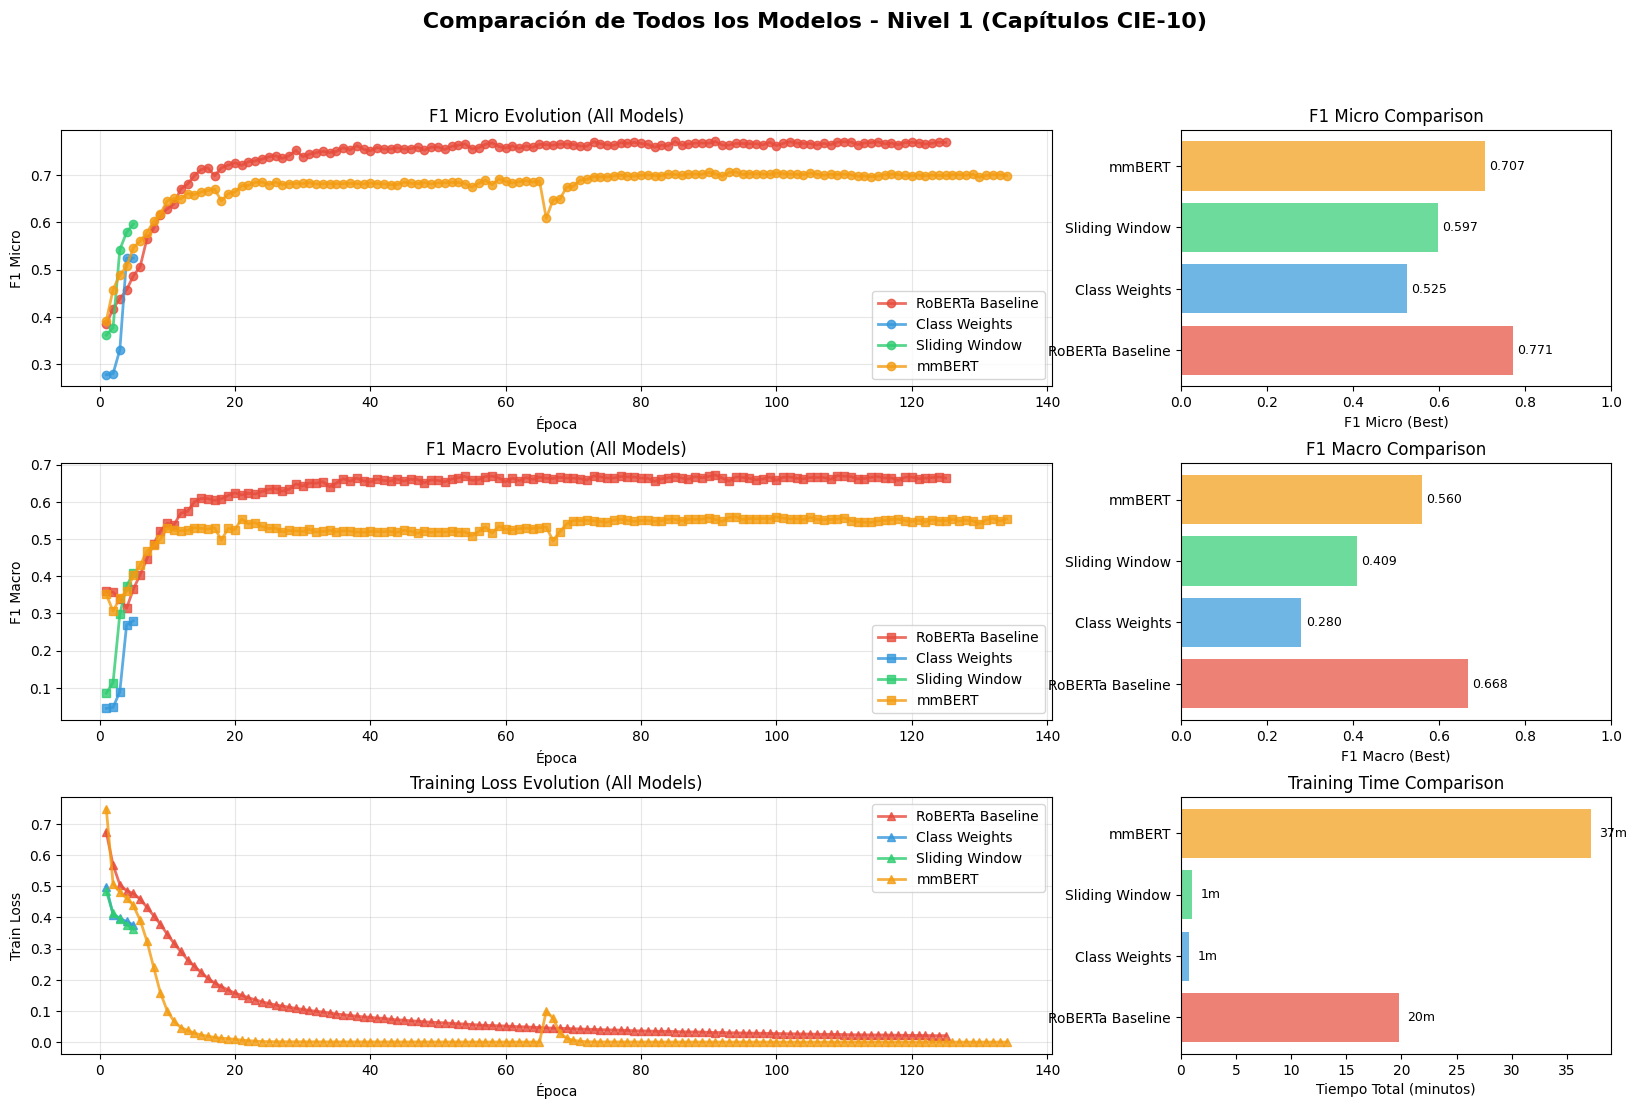

 Tabla comparativa guardada: /home/cie10user/bert-classifier/snapshots/nivel1_capitulos/models_comparison.csv

 Comparación completada!


In [23]:
print("="*80)
print(" COMPARACIÓN FINAL DE TODOS LOS MODELOS - NIVEL 1 (CAPÍTULOS)")
print("="*80 + "\n")

# Lista de modelos a comparar (agregar más según hayas entrenado)
models_to_compare = [
    {
        'name': 'RoBERTa Baseline',
        'path': config.LEVEL1_DIR / 'best_model_roberta_baseline.csv',
        'color': '#e74c3c'
    },
    {
        'name': 'Class Weights',
        'path': config.LEVEL1_DIR / 'best_model_weighted.csv',
        'color': '#3498db'
    },
    {
        'name': 'Sliding Window',
        'path': config.LEVEL1_DIR / 'best_model_sliding_window.csv',
        'color': '#2ecc71'
    },
    {
        'name': 'Longformer',
        'path': config.LEVEL1_DIR / 'best_model_longformer.csv',
        'color': '#9b59b6'
    },
    {
        'name': 'mmBERT',
        'path': config.LEVEL1_DIR / 'best_model_mmbert.csv',
        'color': '#f39c12'
    },
    {
        'name': 'ModernBERT',
        'path': config.LEVEL1_DIR / 'best_model_modernbert.csv',
        'color': '#1abc9c'
    }
]

# Cargar historiales disponibles
results = []
for model_info in models_to_compare:
    csv_path = model_info['path']
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        json_path = csv_path.parent / f"{csv_path.stem}.json"

        # Cargar metadata del JSON
        with open(json_path, 'r') as f:
            history = json.load(f)

        # Obtener mejor resultado
        best_idx = df['dev_f1_micro'].idxmax()
        best_row = df.iloc[best_idx]

        results.append({
            'Modelo': model_info['name'],
            'F1 Micro': best_row['dev_f1_micro'],
            'F1 Macro': best_row['dev_f1_macro'],
            'Precision': best_row['dev_precision'],
            'Recall': best_row['dev_recall'],
            'Train Loss': best_row['train_loss'],
            'Mejor Época': int(best_row['epoch']),
            'LR': history.get('learning_rate', 0),
            'Batch Size': history.get('batch_size', 0),
            'Max Length': history.get('max_length', 0),
            'Tiempo Total (min)': history.get('total_time_seconds', 0) / 60,
            'Tiempo/Época (min)': np.mean(df['epoch_time_sec']) / 60,
            'Color': model_info['color'],
            'History': df
        })
    else:
        print(f"  Modelo '{model_info['name']}' no encontrado: {csv_path}")

if not results:
    print("\n No se encontraron modelos entrenados. Entrena al menos un modelo primero.")
else:
    # Crear DataFrame comparativo
    df_comparison = pd.DataFrame([{
        'Modelo': r['Modelo'],
        'F1 Micro': r['F1 Micro'],
        'F1 Macro': r['F1 Macro'],
        'Precision': r['Precision'],
        'Recall': r['Recall'],
        'Época': r['Mejor Época'],
        'Tiempo (min)': r['Tiempo Total (min)'],
        'LR': r['LR'],
        'Max Len': r['Max Length']
    } for r in results])

    # Ordenar por F1 Micro
    df_comparison = df_comparison.sort_values('F1 Micro', ascending=False)
    df_comparison.insert(0, '', ['' if i == 0 else '' if i == 1 else '' if i == 2 else ''
                                  for i in range(len(df_comparison))])

    print("\n TABLA COMPARATIVA:\n")
    print(df_comparison.to_string(index=False))

    # Identificar mejor modelo
    best_model = results[df_comparison.index[0]]
    print(f"\n{'='*80}")
    print(f" MEJOR MODELO: {best_model['Modelo']}")
    print(f"{'='*80}")
    print(f"   F1 Micro:     {best_model['F1 Micro']:.4f}")
    print(f"   F1 Macro:     {best_model['F1 Macro']:.4f}")
    print(f"   Precision:    {best_model['Precision']:.4f}")
    print(f"   Recall:       {best_model['Recall']:.4f}")
    print(f"   Mejor Época:  {best_model['Mejor Época']}")
    print(f"   Tiempo Total: {best_model['Tiempo Total (min)']:.1f} min")
    print(f"   Max Length:   {best_model['Max Length']} tokens")
    print(f"{'='*80}\n")

    # ============================================================================
    # VISUALIZACIÓN COMPARATIVA
    # ============================================================================
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    fig.suptitle(' Comparación de Todos los Modelos - Nivel 1 (Capítulos CIE-10)',
                 fontsize=16, fontweight='bold')

    # Gráfica 1: F1 Micro por época (todos los modelos)
    ax1 = fig.add_subplot(gs[0, :2])
    for result in results:
        df_hist = result['History']
        ax1.plot(df_hist['epoch'], df_hist['dev_f1_micro'],
                label=result['Modelo'], linewidth=2, marker='o',
                color=result['Color'], alpha=0.8)
    ax1.set_xlabel('Época')
    ax1.set_ylabel('F1 Micro')
    ax1.set_title('F1 Micro Evolution (All Models)')
    ax1.legend(loc='lower right')
    ax1.grid(True, alpha=0.3)

    # Gráfica 2: F1 Macro por época
    ax2 = fig.add_subplot(gs[1, :2])
    for result in results:
        df_hist = result['History']
        ax2.plot(df_hist['epoch'], df_hist['dev_f1_macro'],
                label=result['Modelo'], linewidth=2, marker='s',
                color=result['Color'], alpha=0.8)
    ax2.set_xlabel('Época')
    ax2.set_ylabel('F1 Macro')
    ax2.set_title('F1 Macro Evolution (All Models)')
    ax2.legend(loc='lower right')
    ax2.grid(True, alpha=0.3)

    # Gráfica 3: Train Loss por época
    ax3 = fig.add_subplot(gs[2, :2])
    for result in results:
        df_hist = result['History']
        ax3.plot(df_hist['epoch'], df_hist['train_loss'],
                label=result['Modelo'], linewidth=2, marker='^',
                color=result['Color'], alpha=0.8)
    ax3.set_xlabel('Época')
    ax3.set_ylabel('Train Loss')
    ax3.set_title('Training Loss Evolution (All Models)')
    ax3.legend(loc='upper right')
    ax3.grid(True, alpha=0.3)

    # Gráfica 4: Comparación de F1 Micro (mejor resultado)
    ax4 = fig.add_subplot(gs[0, 2])
    models_names = [r['Modelo'] for r in results]
    f1_micros = [r['F1 Micro'] for r in results]
    colors = [r['Color'] for r in results]
    bars = ax4.barh(models_names, f1_micros, color=colors, alpha=0.7)
    ax4.set_xlabel('F1 Micro (Best)')
    ax4.set_title('F1 Micro Comparison')
    ax4.set_xlim(0, 1)
    for i, (bar, val) in enumerate(zip(bars, f1_micros)):
        ax4.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

    # Gráfica 5: Comparación de F1 Macro
    ax5 = fig.add_subplot(gs[1, 2])
    f1_macros = [r['F1 Macro'] for r in results]
    bars = ax5.barh(models_names, f1_macros, color=colors, alpha=0.7)
    ax5.set_xlabel('F1 Macro (Best)')
    ax5.set_title('F1 Macro Comparison')
    ax5.set_xlim(0, 1)
    for i, (bar, val) in enumerate(zip(bars, f1_macros)):
        ax5.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

    # Gráfica 6: Tiempo de entrenamiento
    ax6 = fig.add_subplot(gs[2, 2])
    times = [r['Tiempo Total (min)'] for r in results]
    bars = ax6.barh(models_names, times, color=colors, alpha=0.7)
    ax6.set_xlabel('Tiempo Total (minutos)')
    ax6.set_title('Training Time Comparison')
    for i, (bar, val) in enumerate(zip(bars, times)):
        ax6.text(val + max(times)*0.02, bar.get_y() + bar.get_height()/2,
                f'{val:.0f}m', va='center', fontsize=9)

    # Guardar figura
    comparison_path = config.LEVEL1_DIR / 'models_comparison.png'
    plt.savefig(comparison_path, dpi=150, bbox_inches='tight')
    print(f" Gráfica comparativa guardada: {comparison_path}")
    plt.show()

    # Guardar tabla comparativa en CSV
    csv_comparison_path = config.LEVEL1_DIR / 'models_comparison.csv'
    df_comparison.to_csv(csv_comparison_path, index=False)
    print(f" Tabla comparativa guardada: {csv_comparison_path}")

    print(f"\n{'='*80}")
    print(" Comparación completada!")
    print(f"{'='*80}")